## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [9]:
SCENARIO = 'optimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

In [10]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic


In [11]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [12]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [13]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [14]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/50cars


##### *Initialisation*

In [15]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [16]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:17:45.739 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-28 23:17:45.797 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-28 23:17:45.845 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-28 23:17:45.940 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-28 23:17:45.959 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-28 23:17:46.062 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-28 23:17:46.066 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-28 23:17:46.153 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-28 23:17:46.402 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-28 23:17:46.471 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-28 23:17:46.507 | IN

##### *Metrics*

In [17]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 4.88 kWh
  Station 1: 0.00 kWh
  Station 2: 1.75 kWh
  Station 3: 5.17 kWh
  Station 4: 1.73 kWh
  Station 5: 9.49 kWh
  Station 6: 17.59 kWh
  Station 7: 8.09 kWh
  Station 8: 0.00 kWh
  Station 9: 8.01 kWh
  Station 10: 0.00 kWh
  Station 11: 1.54 kWh
  Station 12: 0.00 kWh
  Station 13: 3.73 kWh
  Station 14: 7.11 kWh
  Station 15: 80.90 kWh
  Station 16: 1.45 kWh
  Station 17: 20.00 kWh
  Station 18: 20.12 kWh
  Station 19: 82.83 kWh
  Station 20: 4.22 kWh
  Station 21: 24.70 kWh
  Station 22: 3.92 kWh
  Station 23: 1.73 kWh
  Station 24: 56.12 kWh
  Station 25: 21.47 kWh
  Station 26: 3.62 kWh
  Station 27: 57.79 kWh
  Station 28: 0.00 kWh
  Station 29: 11.00 kWh
  Station 30: 2.10 kWh
  Station 31: 4.05 kWh
  Station 32: 3.95 kWh
  Station 33: 5.81 kWh
  Station 34: 15.52 kWh
  Station 35: 14.00 kWh
  Station 36: 3.10 kWh
  Station 37: 29.08 kWh
  Station 38: 0.00 kWh
  Station 39: 26.13 kWh

--- User Req

In [18]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

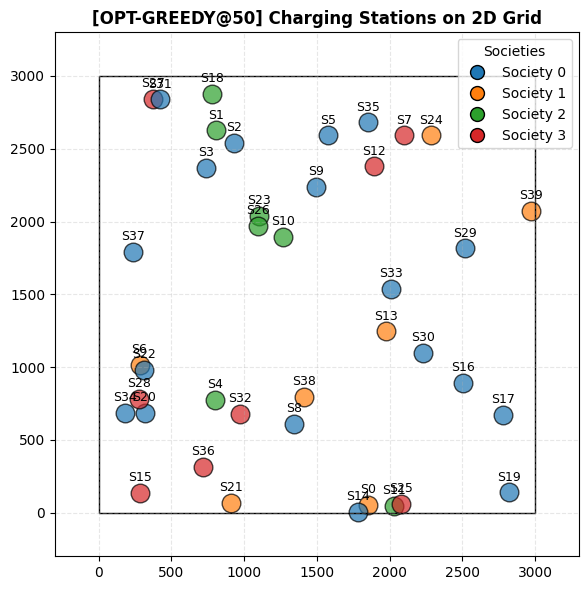

In [19]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

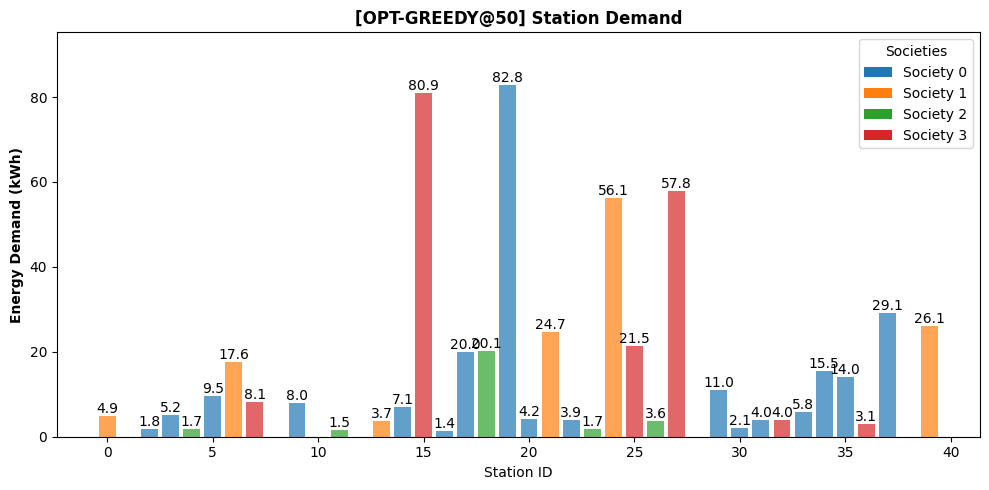

In [20]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

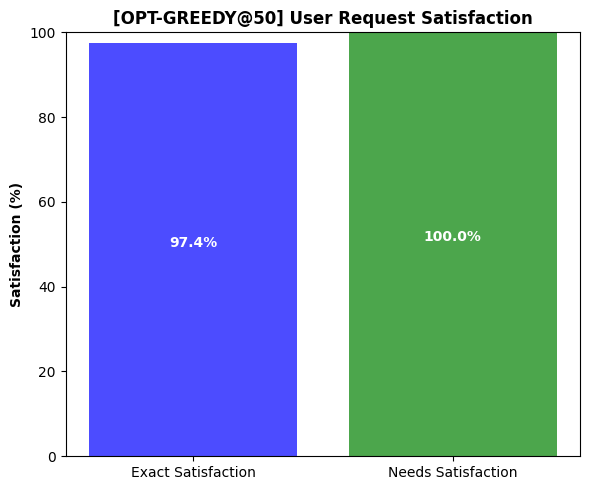

In [21]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

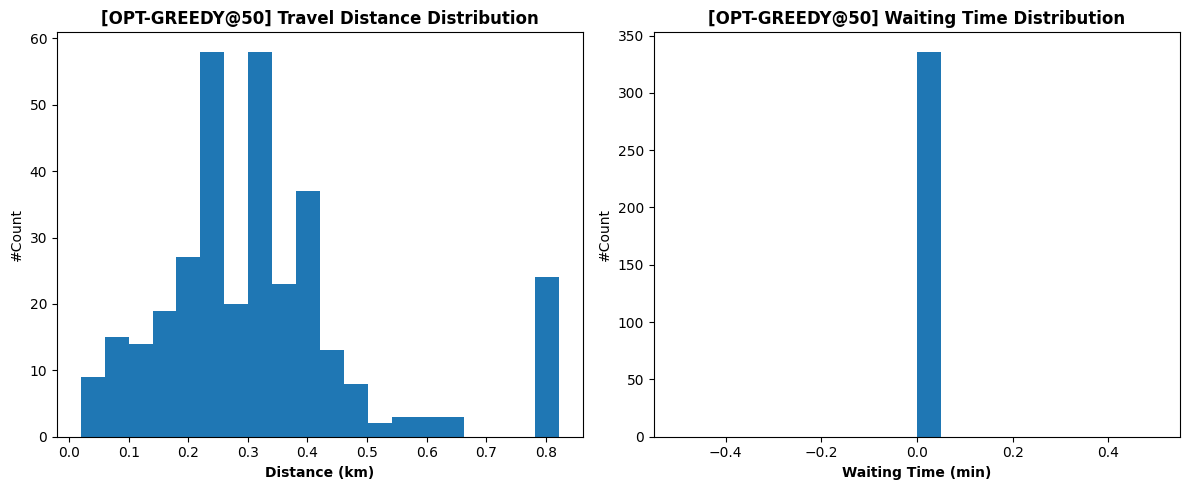

In [22]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

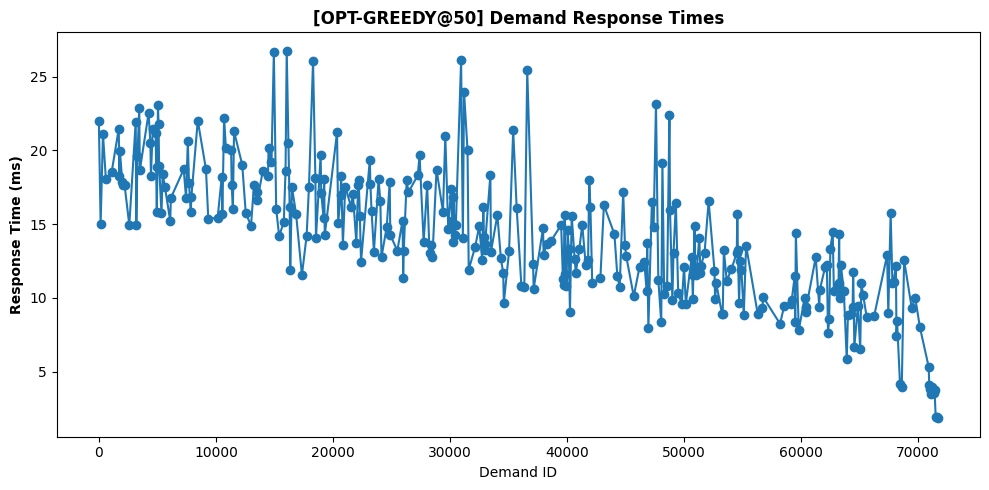

In [23]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

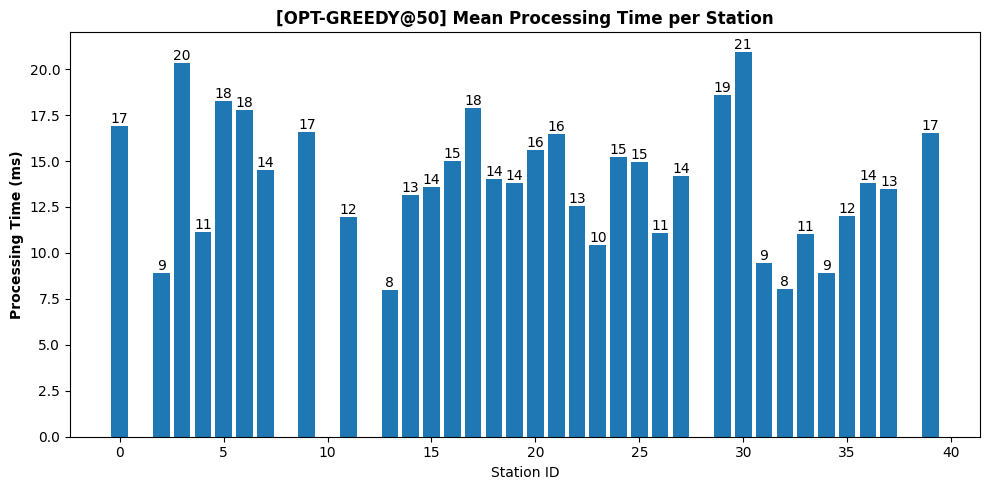

In [24]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [25]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/50cars


##### *Initialisation*

In [26]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [27]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:17:52.424 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-28 23:17:52.599 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-28 23:17:52.852 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-28 23:17:53.474 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-28 23:17:53.969 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-28 23:17:54.586 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-28 23:17:54.899 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-28 23:17:54.904 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-28 23:17:55.324 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-28 23:17:55.988 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-28 23:17:56.582 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [28]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 7.86 kWh
  Station 1: 8.88 kWh
  Station 2: 1.07 kWh
  Station 3: 3.03 kWh
  Station 4: 56.92 kWh
  Station 5: 2.05 kWh
  Station 6: 31.12 kWh
  Station 7: 0.00 kWh
  Station 8: 5.97 kWh
  Station 9: 3.67 kWh
  Station 10: 0.00 kWh
  Station 11: 21.47 kWh
  Station 12: 6.68 kWh
  Station 13: 3.85 kWh
  Station 14: 0.00 kWh
  Station 15: 13.23 kWh
  Station 16: 56.35 kWh
  Station 17: 19.25 kWh
  Station 18: 7.35 kWh
  Station 19: 3.29 kWh
  Station 20: 1.08 kWh
  Station 21: 19.57 kWh
  Station 22: 1.93 kWh
  Station 23: 12.08 kWh
  Station 24: 5.17 kWh
  Station 25: 3.70 kWh
  Station 26: 3.91 kWh
  Station 27: 59.82 kWh
  Station 28: 1.43 kWh
  Station 29: 0.00 kWh
  Station 30: 5.92 kWh
  Station 31: 32.43 kWh
  Station 32: 1.73 kWh
  Station 33: 19.07 kWh
  Station 34: 27.80 kWh
  Station 35: 23.43 kWh
  Station 36: 59.19 kWh
  Station 37: 24.02 kWh
  Station 38: 0.00 kWh
  Station 39: 2.13 kWh

--- User Re

In [29]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

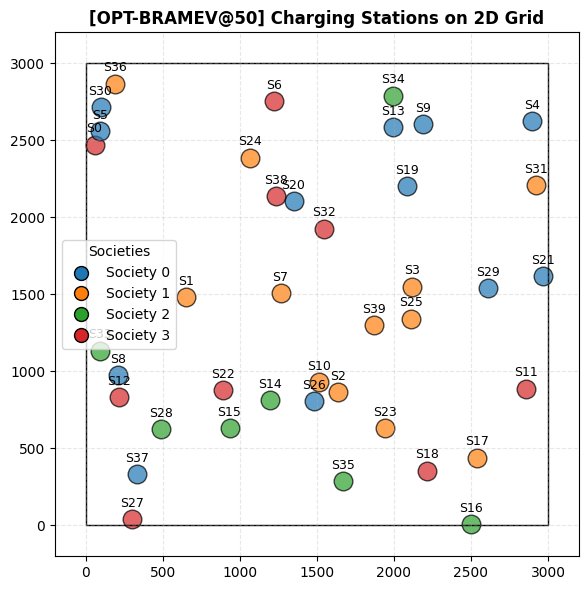

In [30]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

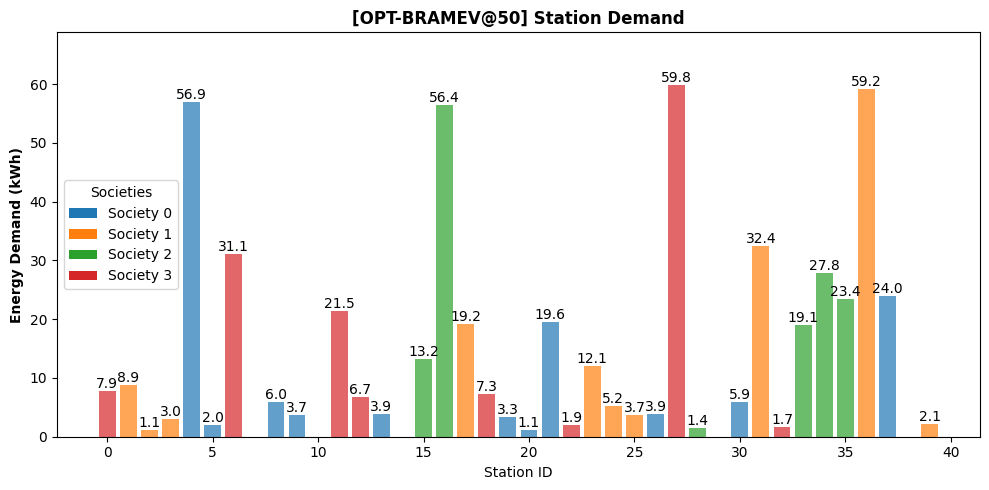

In [31]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

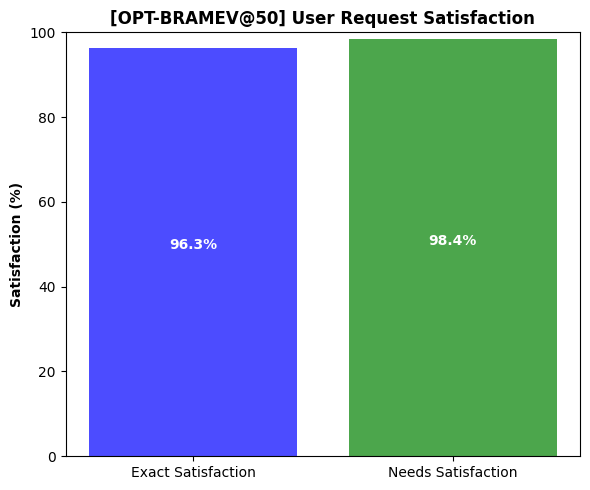

In [32]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

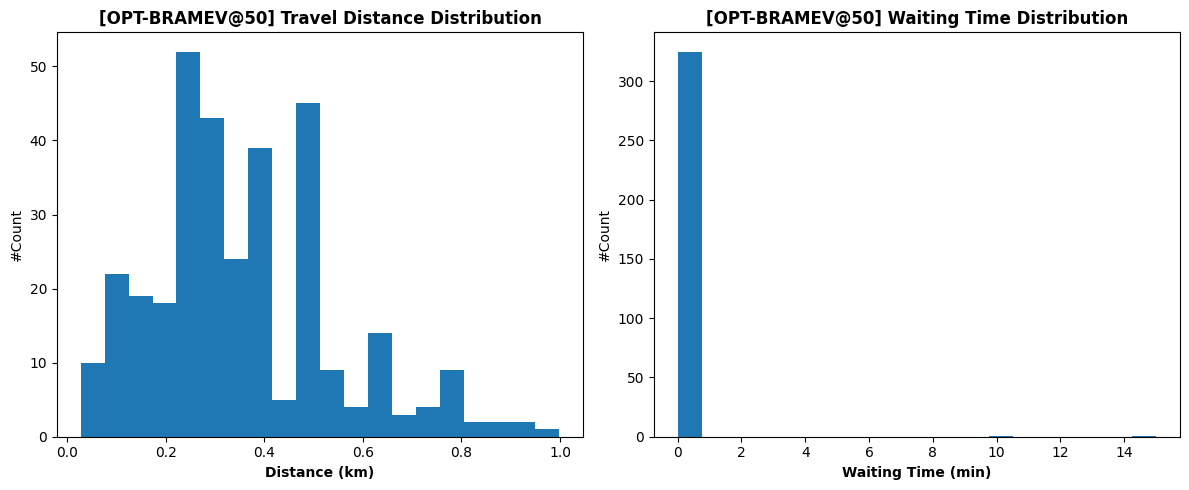

In [33]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

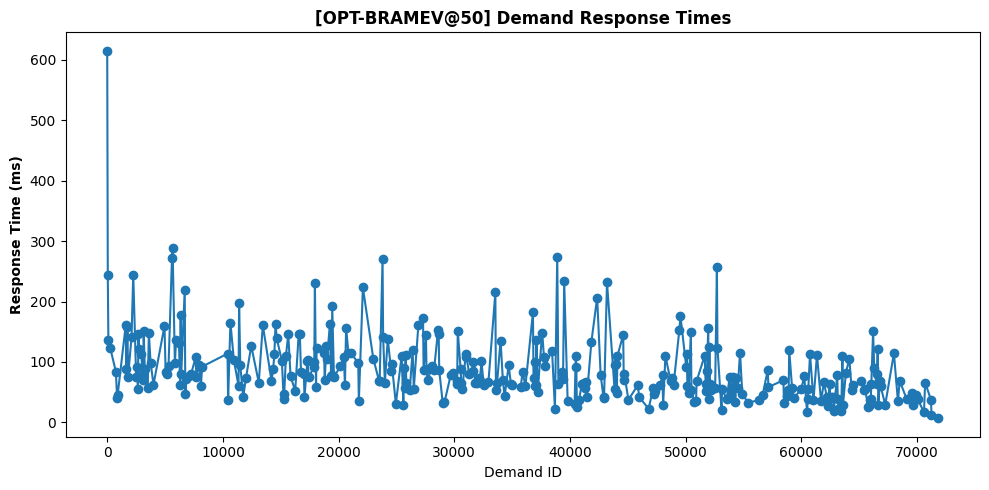

In [34]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

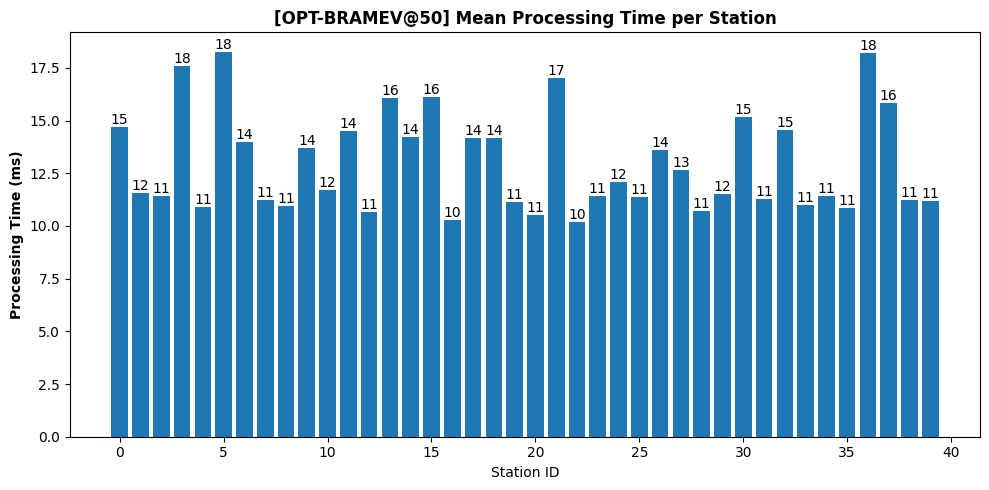

In [35]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [36]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

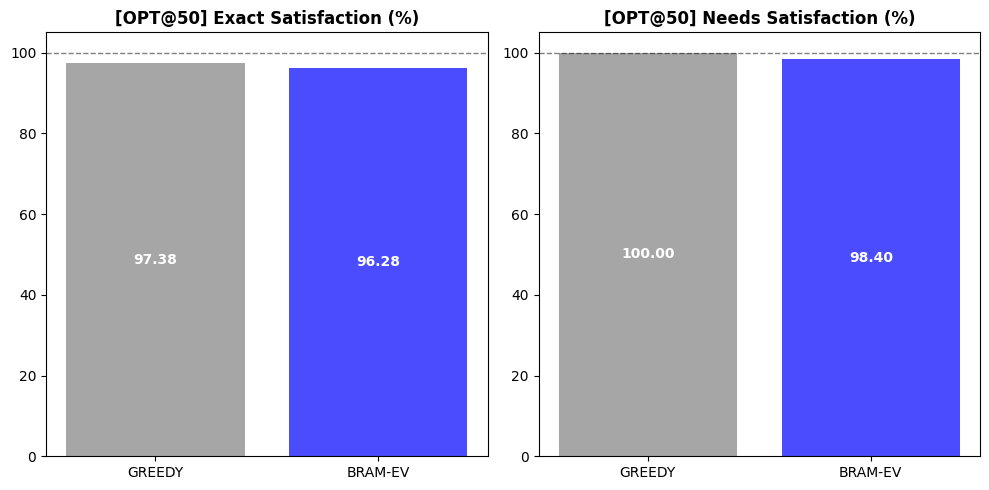

In [37]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

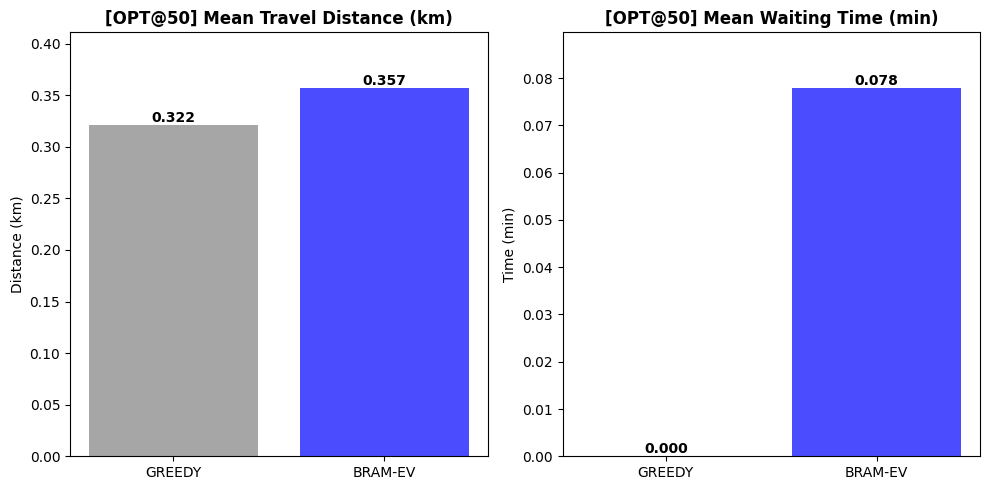

In [38]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

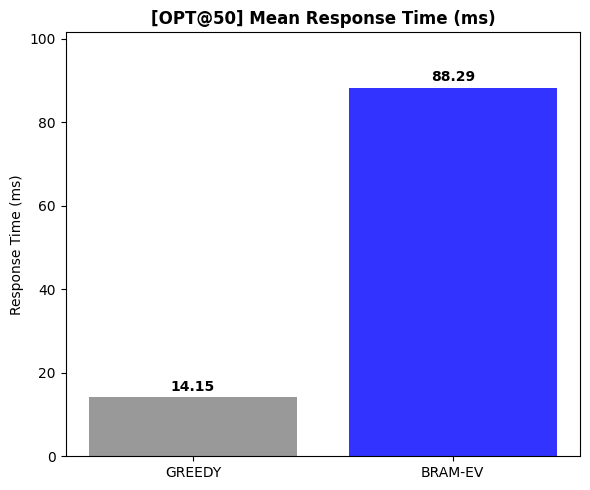

In [39]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [40]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [41]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/100cars


##### *Initialisation*

In [42]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [43]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:18:22.470 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-28 23:18:22.572 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-28 23:18:22.715 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-28 23:18:22.769 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-28 23:18:22.922 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-28 23:18:23.028 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-28 23:18:23.165 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-28 23:18:23.335 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-28 23:18:23.449 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-28 23:18:23.574 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-28 23:18:23.734 | IN

##### *Metrics*

In [44]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 7.94 kWh
  Station 1: 3.77 kWh
  Station 2: 0.00 kWh
  Station 3: 3.79 kWh
  Station 4: 12.07 kWh
  Station 5: 126.52 kWh
  Station 6: 27.28 kWh
  Station 7: 0.00 kWh
  Station 8: 0.00 kWh
  Station 9: 31.99 kWh
  Station 10: 40.69 kWh
  Station 11: 14.04 kWh
  Station 12: 17.64 kWh
  Station 13: 189.99 kWh
  Station 14: 3.42 kWh
  Station 15: 3.17 kWh
  Station 16: 8.69 kWh
  Station 17: 15.36 kWh
  Station 18: 1.58 kWh
  Station 19: 8.14 kWh
  Station 20: 0.00 kWh
  Station 21: 23.71 kWh
  Station 22: 6.27 kWh
  Station 23: 2.12 kWh
  Station 24: 4.15 kWh
  Station 25: 25.77 kWh
  Station 26: 2.73 kWh
  Station 27: 5.67 kWh
  Station 28: 1.69 kWh
  Station 29: 9.37 kWh
  Station 30: 158.86 kWh
  Station 31: 125.03 kWh
  Station 32: 1.45 kWh
  Station 33: 30.63 kWh
  Station 34: 10.08 kWh
  Station 35: 23.88 kWh
  Station 36: 5.41 kWh
  Station 37: 64.25 kWh
  Station 38: 74.37 kWh
  Station 39: 12.09 kWh

---

In [45]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

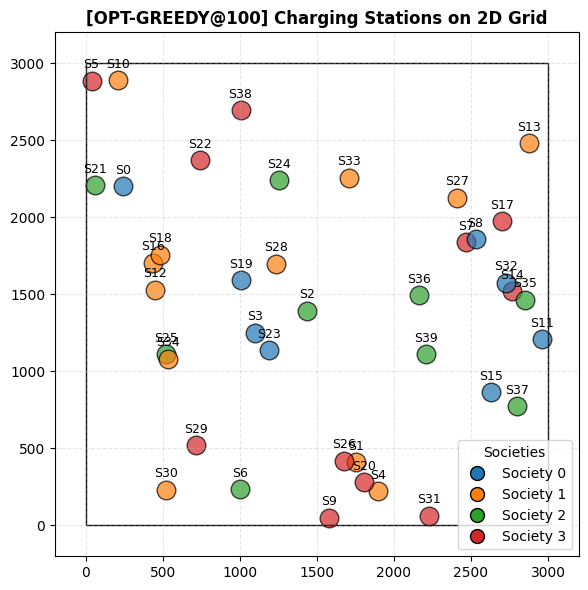

In [46]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

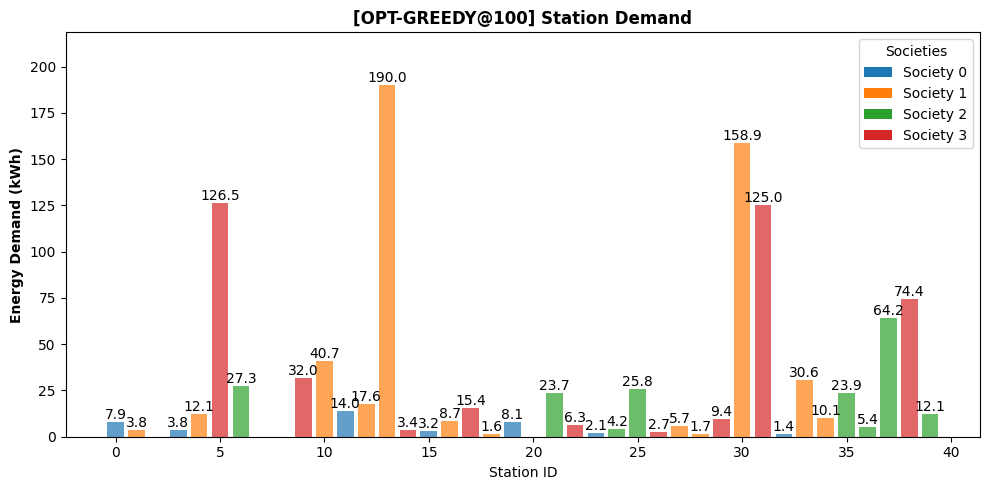

In [47]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

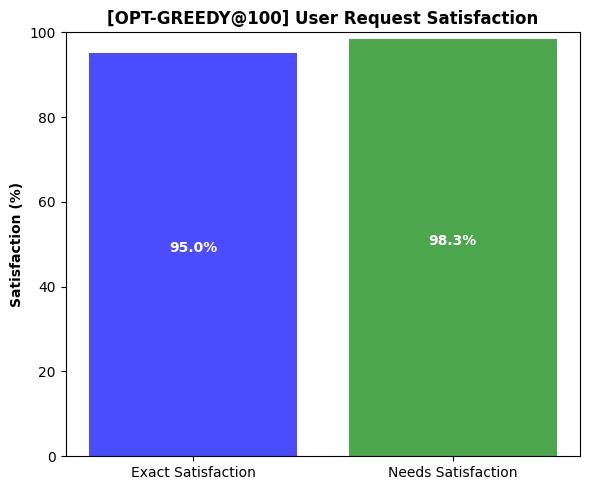

In [48]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

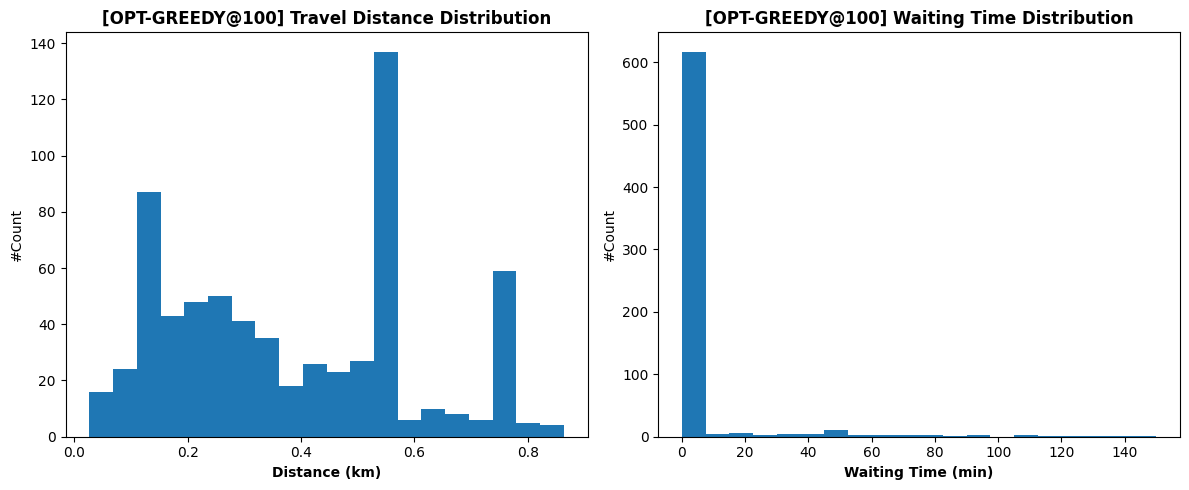

In [49]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

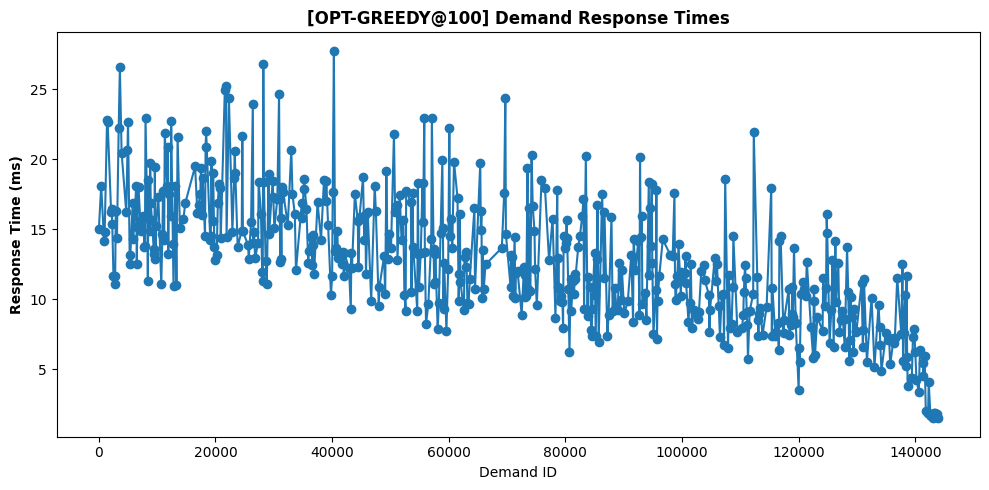

In [50]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

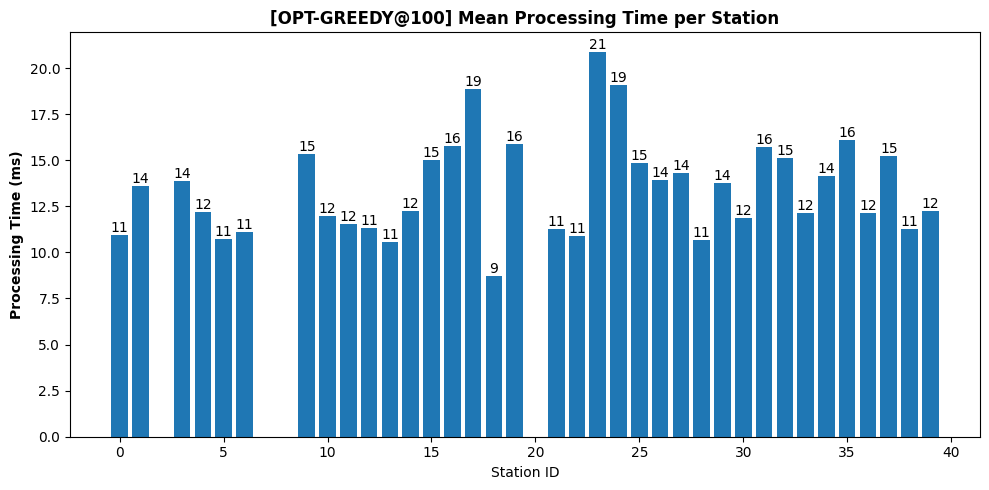

In [51]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [52]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/100cars


##### *Initialisation*

In [53]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [54]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:18:35.064 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-28 23:18:35.923 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-28 23:18:36.599 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-28 23:18:36.831 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-28 23:18:37.420 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-28 23:18:38.798 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-28 23:18:39.587 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-28 23:18:40.778 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-28 23:18:41.578 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-28 23:18:42.127 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-28 23:18:43.818 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [55]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 4.05 kWh
  Station 1: 85.47 kWh
  Station 2: 3.87 kWh
  Station 3: 16.64 kWh
  Station 4: 53.27 kWh
  Station 5: 15.41 kWh
  Station 6: 6.28 kWh
  Station 7: 5.90 kWh
  Station 8: 44.50 kWh
  Station 9: 27.69 kWh
  Station 10: 4.95 kWh
  Station 11: 14.96 kWh
  Station 12: 10.76 kWh
  Station 13: 10.17 kWh
  Station 14: 26.31 kWh
  Station 15: 101.65 kWh
  Station 16: 2.80 kWh
  Station 17: 37.44 kWh
  Station 18: 2.83 kWh
  Station 19: 13.54 kWh
  Station 20: 10.63 kWh
  Station 21: 15.77 kWh
  Station 22: 6.24 kWh
  Station 23: 31.02 kWh
  Station 24: 40.10 kWh
  Station 25: 7.20 kWh
  Station 26: 2.98 kWh
  Station 27: 5.97 kWh
  Station 28: 14.07 kWh
  Station 29: 37.79 kWh
  Station 30: 5.28 kWh
  Station 31: 96.93 kWh
  Station 32: 63.35 kWh
  Station 33: 72.63 kWh
  Station 34: 36.12 kWh
  Station 35: 113.22 kWh
  Station 36: 13.03 kWh
  Station 37: 4.96 kWh
  Station 38: 6.79 kWh
  Station 39: 31.68 kWh

In [56]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

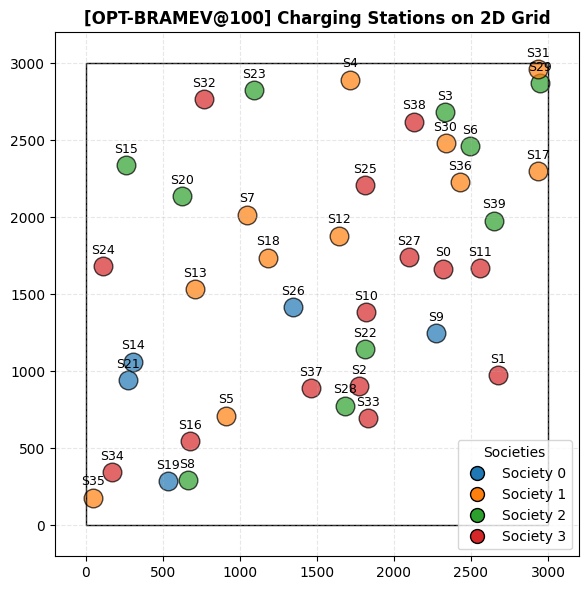

In [57]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

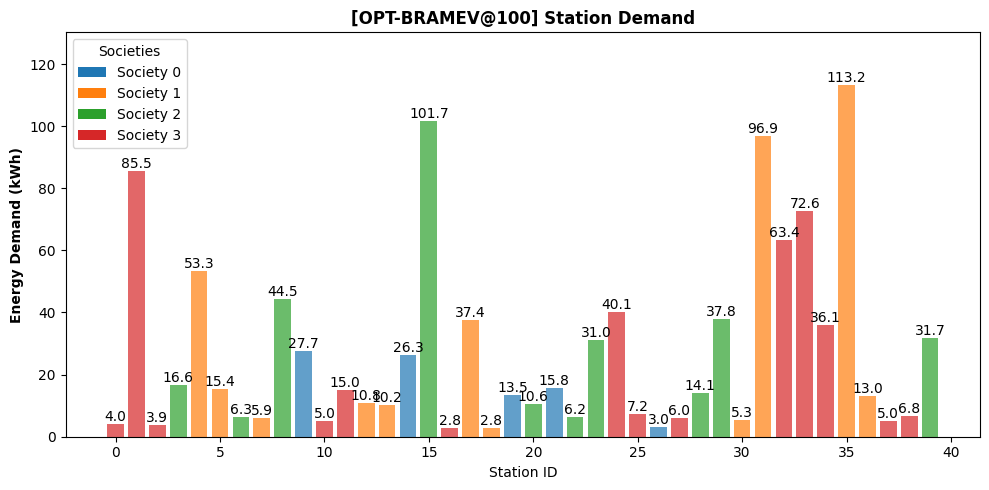

In [58]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

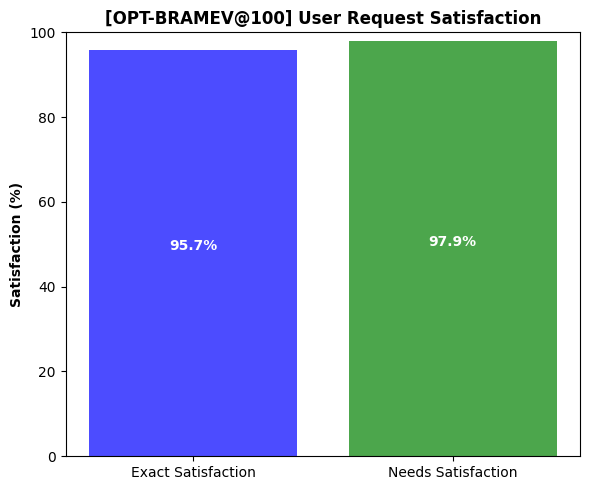

In [59]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

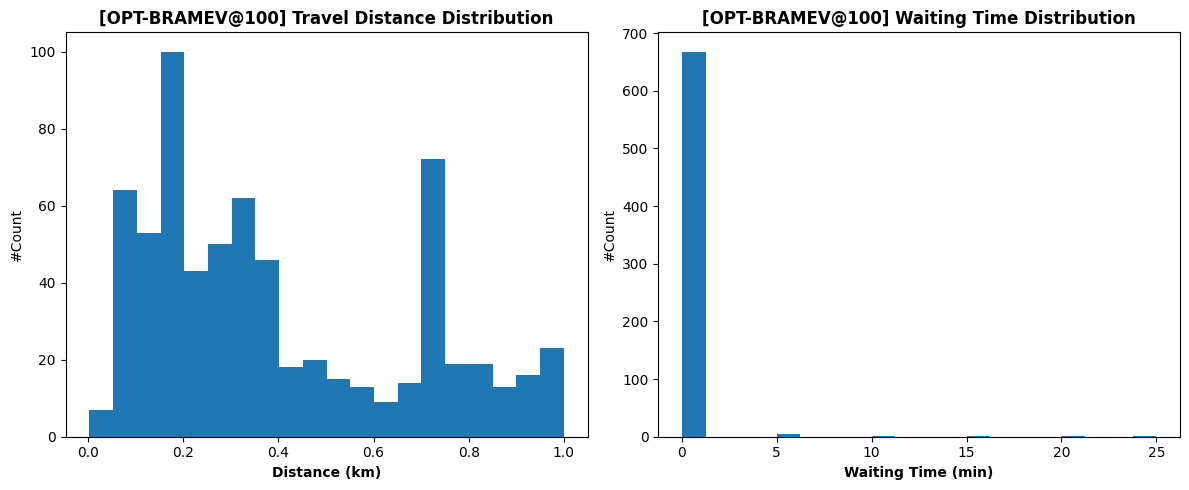

In [60]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

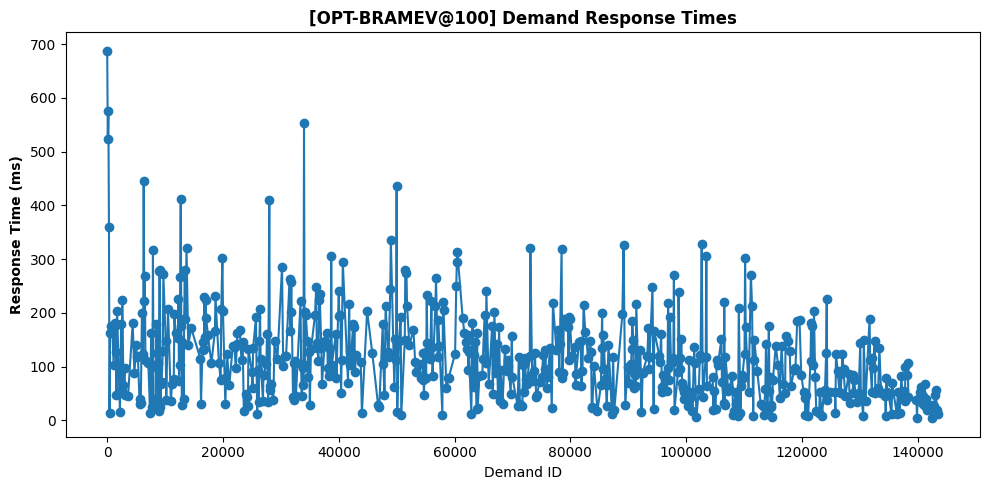

In [61]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

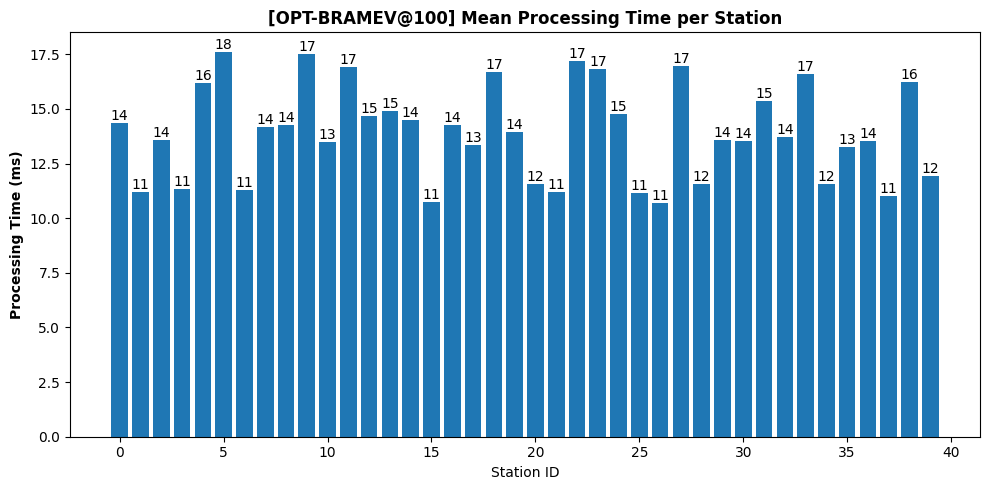

In [62]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [63]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

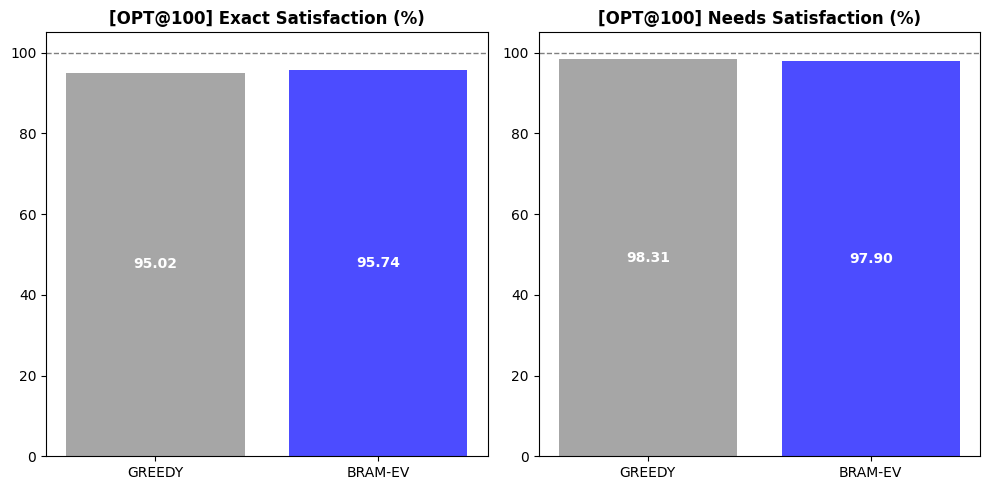

In [64]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

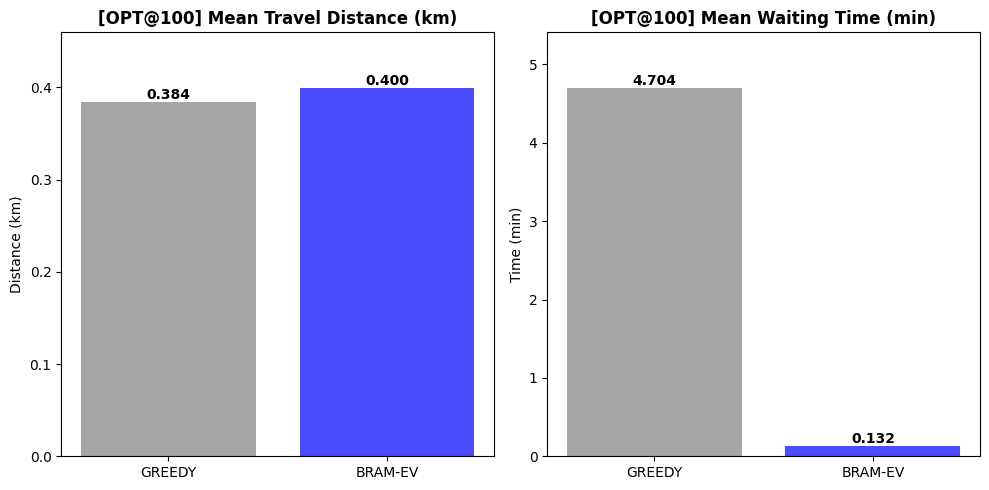

In [65]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

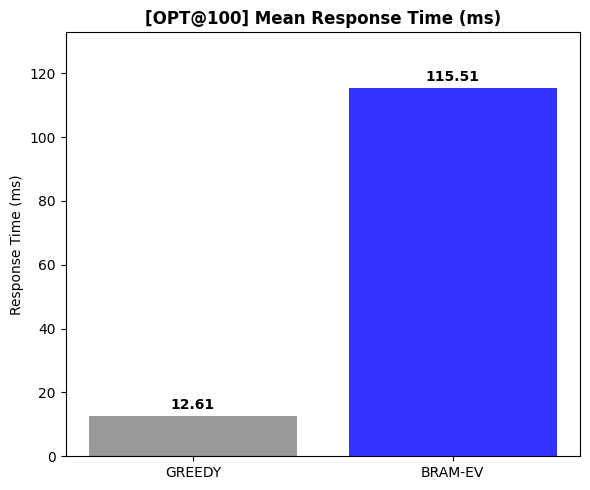

In [66]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [67]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [68]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/150cars


##### *Initialisation*

In [69]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [70]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:19:45.494 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-28 23:19:45.705 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-28 23:19:46.002 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-28 23:19:46.327 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-28 23:19:46.562 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-28 23:19:46.803 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-28 23:19:47.062 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-28 23:19:47.260 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-28 23:19:47.408 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-28 23:19:47.569 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-28 23:19:47.723 | IN

##### *Metrics*

In [71]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 9.03 kWh
  Station 1: 194.50 kWh
  Station 2: 12.55 kWh
  Station 3: 6.91 kWh
  Station 4: 31.40 kWh
  Station 5: 29.09 kWh
  Station 6: 5.63 kWh
  Station 7: 16.75 kWh
  Station 8: 0.00 kWh
  Station 9: 52.27 kWh
  Station 10: 186.74 kWh
  Station 11: 5.85 kWh
  Station 12: 273.10 kWh
  Station 13: 15.96 kWh
  Station 14: 5.03 kWh
  Station 15: 8.30 kWh
  Station 16: 8.68 kWh
  Station 17: 4.66 kWh
  Station 18: 31.53 kWh
  Station 19: 10.25 kWh
  Station 20: 3.76 kWh
  Station 21: 46.23 kWh
  Station 22: 6.22 kWh
  Station 23: 10.16 kWh
  Station 24: 48.88 kWh
  Station 25: 9.47 kWh
  Station 26: 48.50 kWh
  Station 27: 76.53 kWh
  Station 28: 12.60 kWh
  Station 29: 9.35 kWh
  Station 30: 3.52 kWh
  Station 31: 32.50 kWh
  Station 32: 15.81 kWh
  Station 33: 27.29 kWh
  Station 34: 89.06 kWh
  Station 35: 3.20 kWh
  Station 36: 3.47 kWh
  Station 37: 6.12 kWh
  Station 38: 221.03 kWh
  Station 39: 93.78 kWh


In [72]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

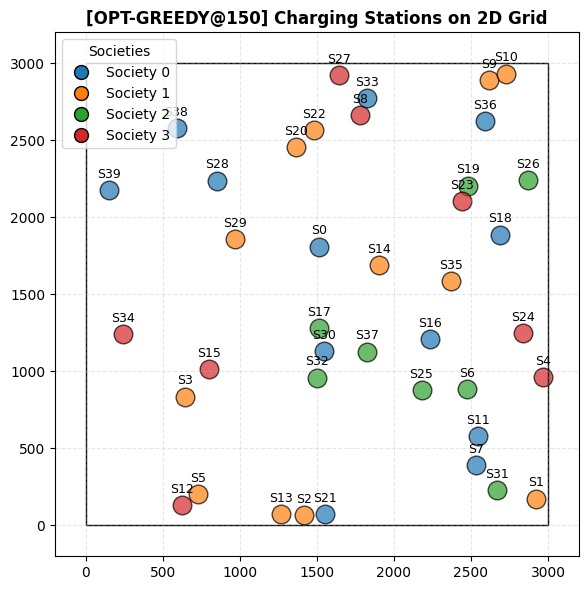

In [73]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

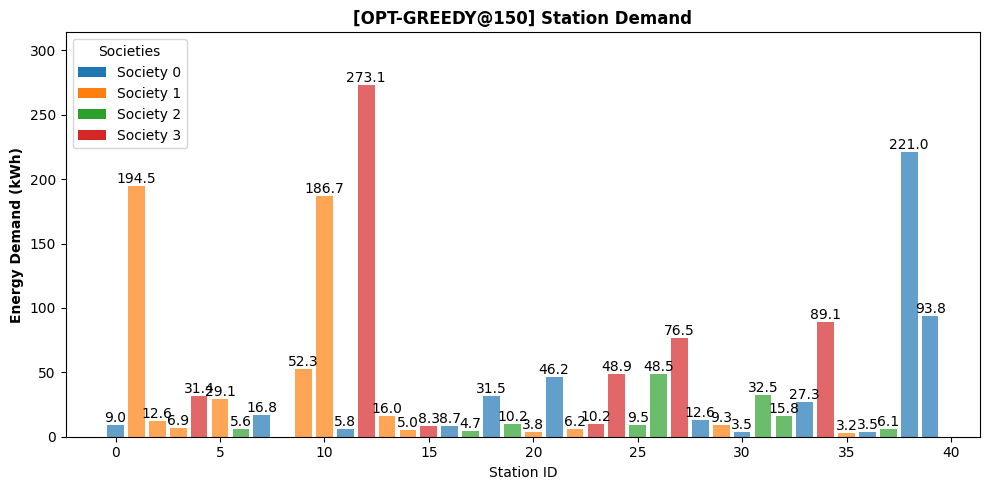

In [74]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

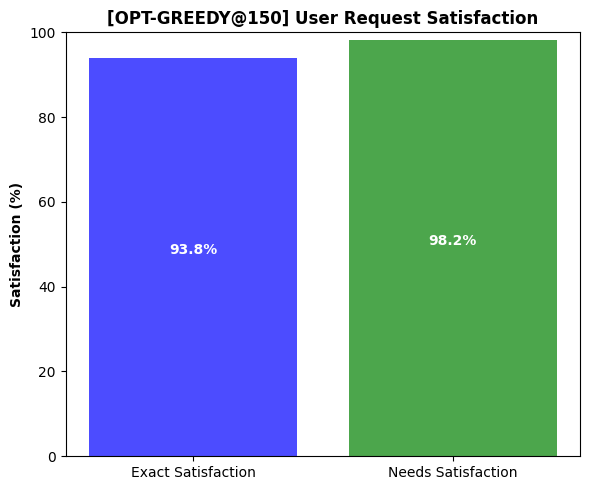

In [75]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

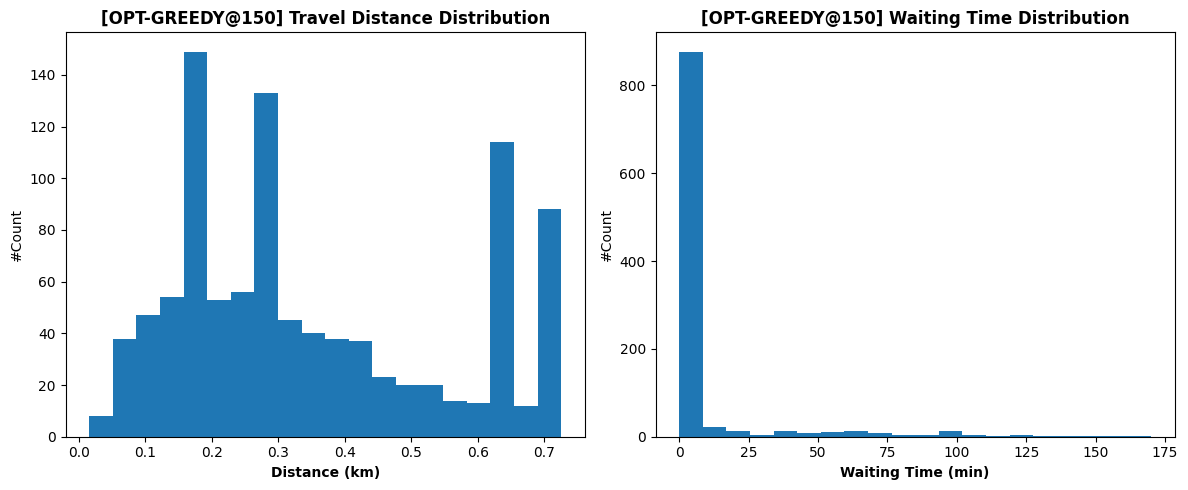

In [76]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

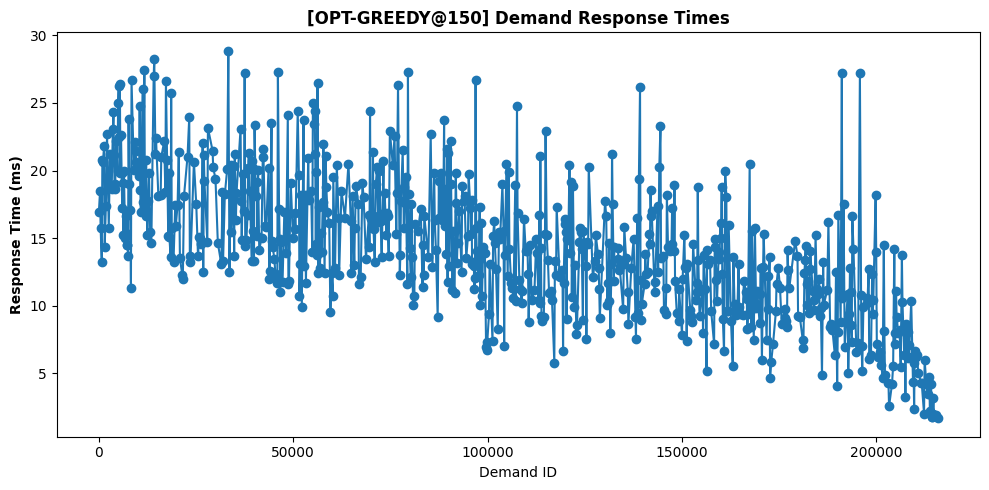

In [77]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

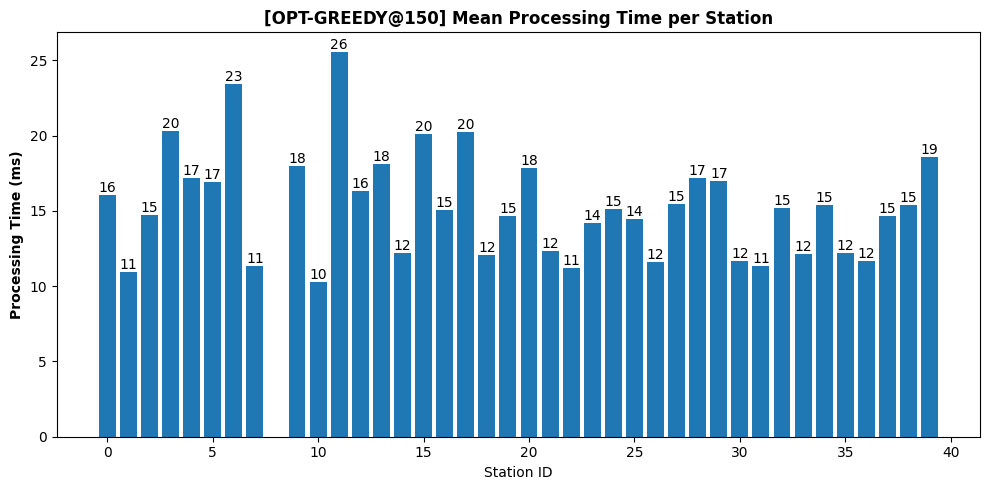

In [78]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [79]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/150cars


##### *Initialisation*

In [80]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [81]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:20:05.553 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-28 23:20:06.066 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-28 23:20:07.550 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-28 23:20:08.570 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-28 23:20:09.872 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-28 23:20:10.845 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-28 23:20:12.174 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-28 23:20:13.293 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-28 23:20:14.427 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-28 23:20:15.320 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-28 23:20:17.926 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [82]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 14.43 kWh
  Station 1: 4.93 kWh
  Station 2: 92.39 kWh
  Station 3: 56.38 kWh
  Station 4: 37.40 kWh
  Station 5: 140.97 kWh
  Station 6: 16.38 kWh
  Station 7: 37.18 kWh
  Station 8: 8.41 kWh
  Station 9: 56.43 kWh
  Station 10: 10.71 kWh
  Station 11: 189.06 kWh
  Station 12: 187.30 kWh
  Station 13: 9.28 kWh
  Station 14: 27.84 kWh
  Station 15: 6.67 kWh
  Station 16: 24.70 kWh
  Station 17: 35.32 kWh
  Station 18: 50.79 kWh
  Station 19: 2.51 kWh
  Station 20: 19.29 kWh
  Station 21: 69.03 kWh
  Station 22: 10.79 kWh
  Station 23: 10.74 kWh
  Station 24: 10.44 kWh
  Station 25: 10.42 kWh
  Station 26: 10.97 kWh
  Station 27: 193.47 kWh
  Station 28: 56.56 kWh
  Station 29: 90.81 kWh
  Station 30: 15.96 kWh
  Station 31: 41.49 kWh
  Station 32: 35.86 kWh
  Station 33: 2.30 kWh
  Station 34: 29.57 kWh
  Station 35: 5.60 kWh
  Station 36: 13.92 kWh
  Station 37: 29.23 kWh
  Station 38: 7.97 kWh
  Station 39: 8

In [83]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

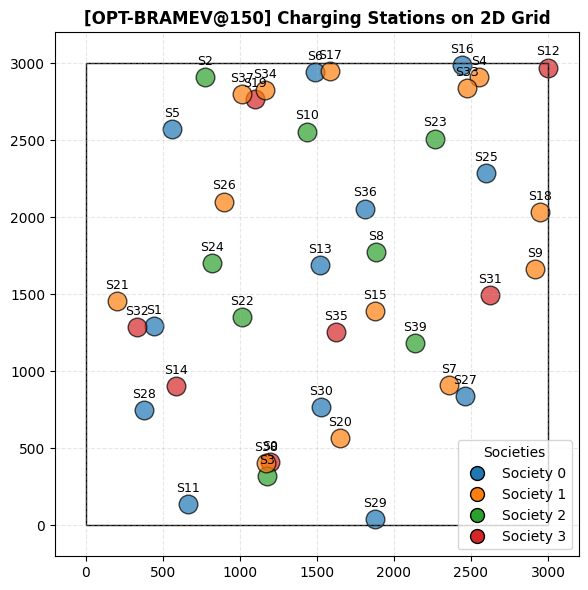

In [84]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

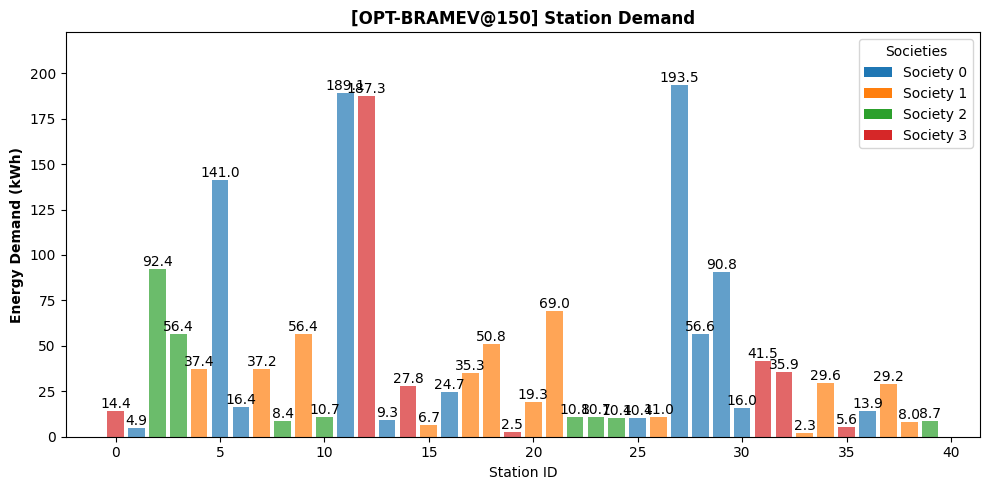

In [85]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

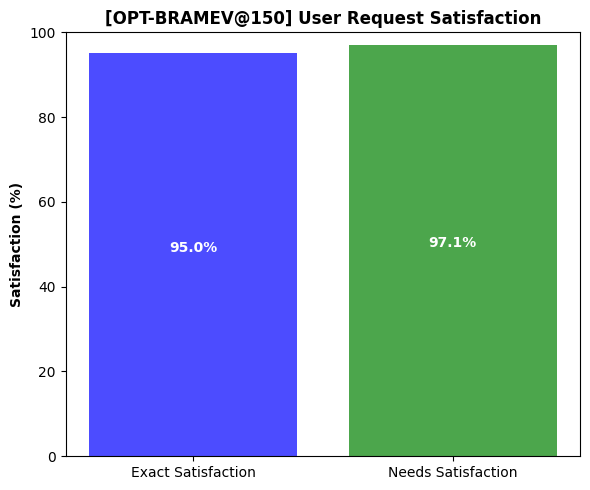

In [86]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

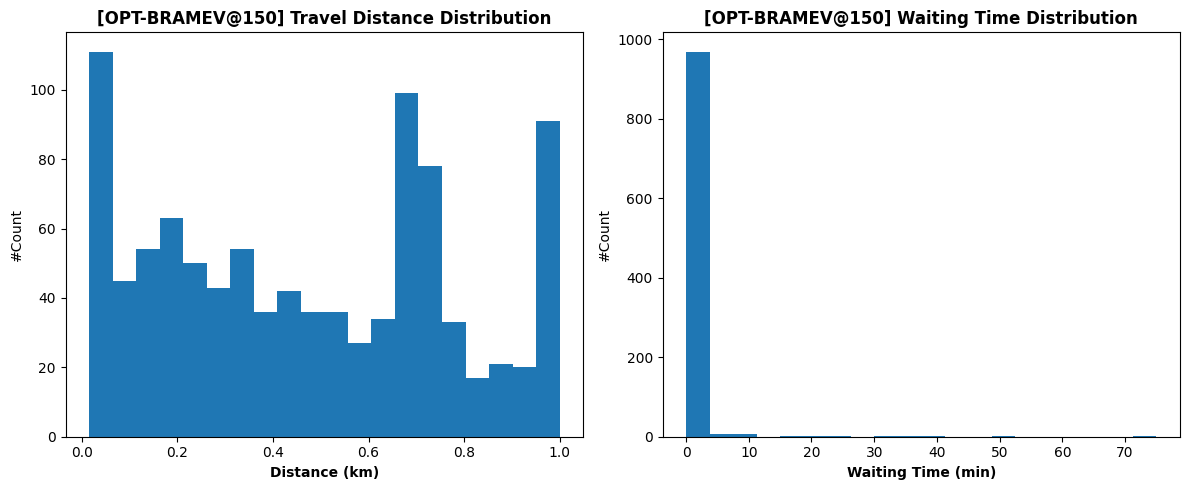

In [87]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

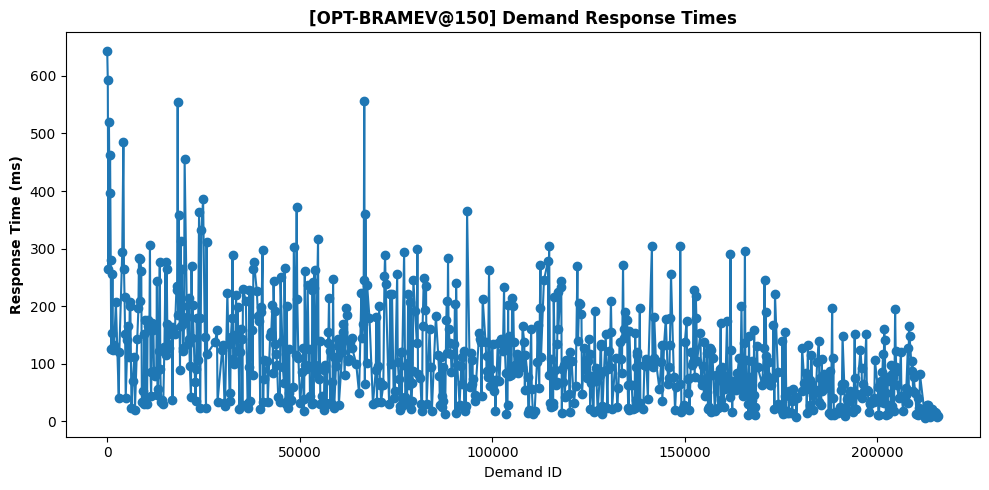

In [88]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

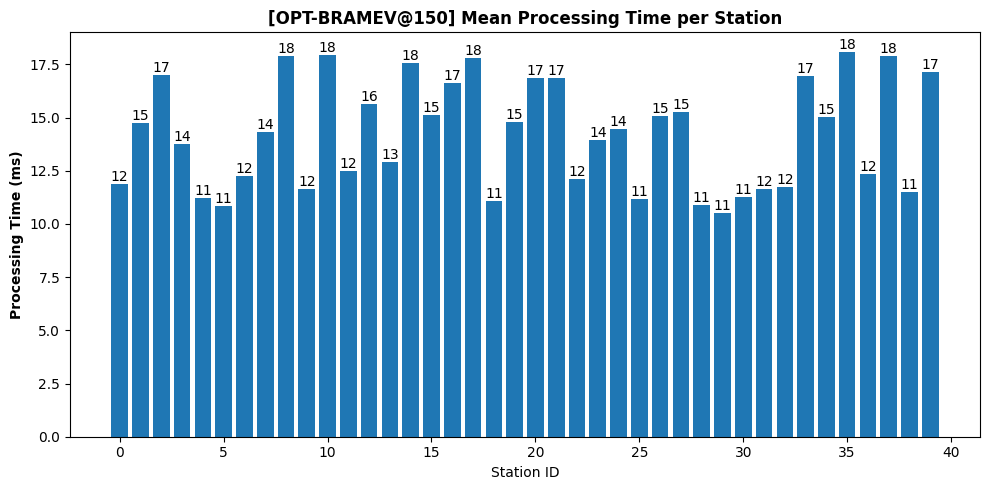

In [89]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [90]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

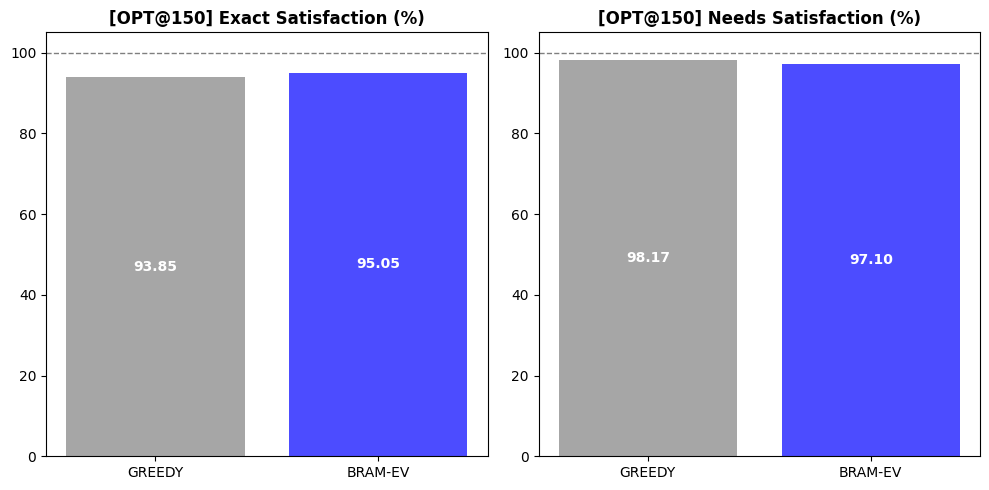

In [91]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

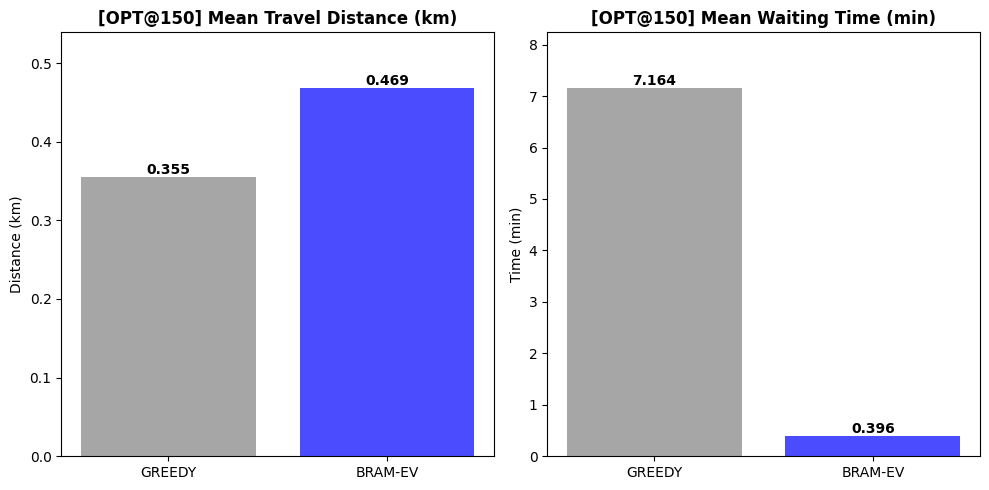

In [92]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

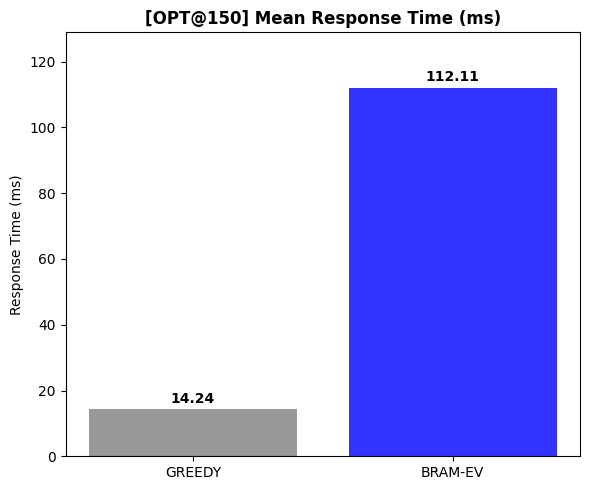

In [93]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [94]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [95]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/200cars


##### *Initialisation*

In [96]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [97]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:21:35.326 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-28 23:21:35.610 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-28 23:21:35.880 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-28 23:21:36.141 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-28 23:21:36.408 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-28 23:21:36.771 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-28 23:21:37.075 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-28 23:21:37.226 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-28 23:21:37.398 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-28 23:21:37.749 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-28 23:21:37.937 | IN

##### *Metrics*

In [98]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 97.22 kWh
  Station 1: 7.22 kWh
  Station 2: 324.50 kWh
  Station 3: 325.51 kWh
  Station 4: 2.73 kWh
  Station 5: 7.61 kWh
  Station 6: 63.29 kWh
  Station 7: 93.97 kWh
  Station 8: 12.69 kWh
  Station 9: 17.99 kWh
  Station 10: 93.02 kWh
  Station 11: 6.87 kWh
  Station 12: 5.40 kWh
  Station 13: 57.55 kWh
  Station 14: 1.87 kWh
  Station 15: 50.12 kWh
  Station 16: 256.50 kWh
  Station 17: 6.96 kWh
  Station 18: 10.43 kWh
  Station 19: 94.28 kWh
  Station 20: 5.78 kWh
  Station 21: 111.71 kWh
  Station 22: 88.03 kWh
  Station 23: 1.25 kWh
  Station 24: 9.09 kWh
  Station 25: 29.76 kWh
  Station 26: 8.42 kWh
  Station 27: 9.42 kWh
  Station 28: 10.22 kWh
  Station 29: 54.62 kWh
  Station 30: 0.00 kWh
  Station 31: 2.67 kWh
  Station 32: 6.60 kWh
  Station 33: 207.81 kWh
  Station 34: 8.02 kWh
  Station 35: 1.91 kWh
  Station 36: 5.88 kWh
  Station 37: 1.69 kWh
  Station 38: 51.31 kWh
  Station 39: 6.97 kWh

-

In [99]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

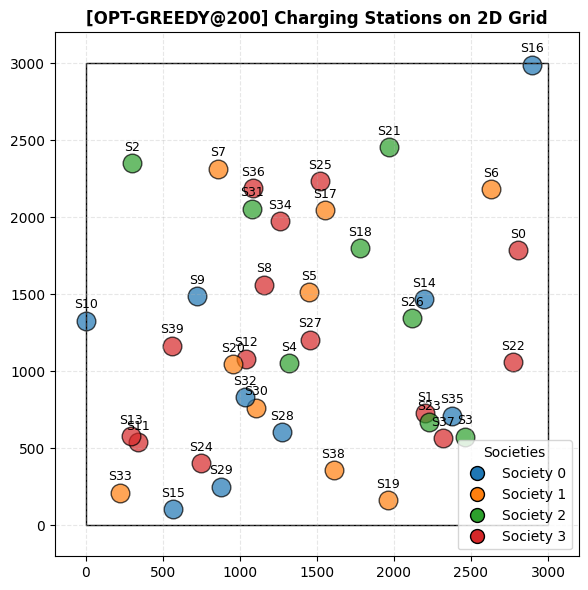

In [100]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

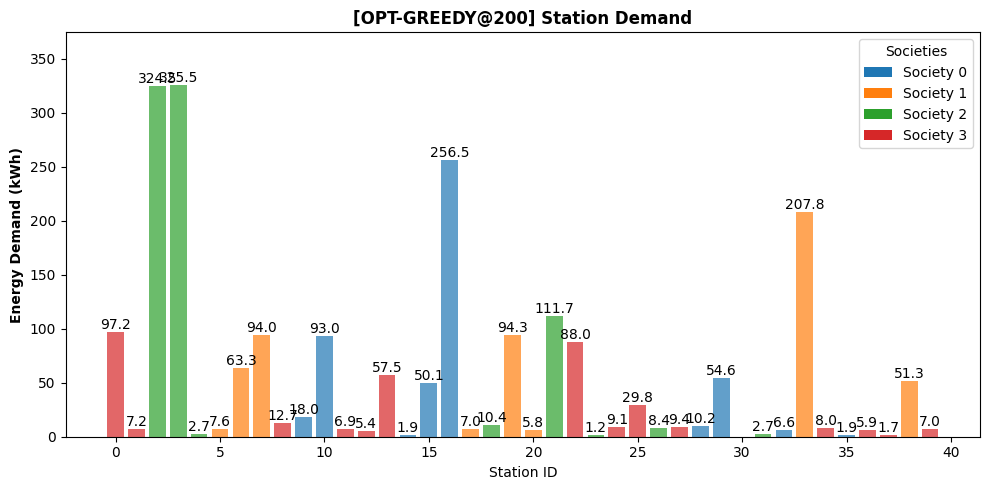

In [101]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

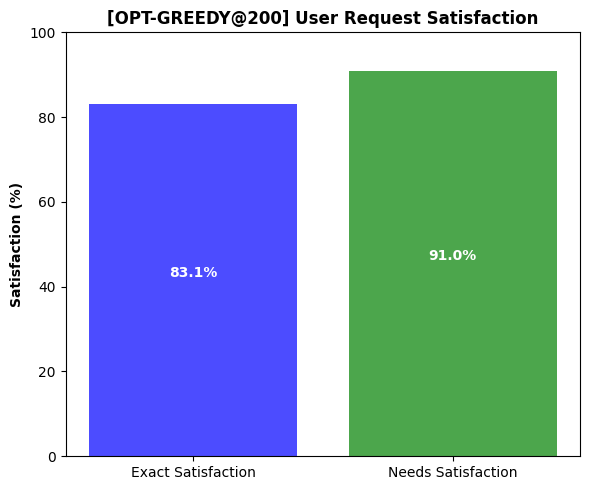

In [102]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

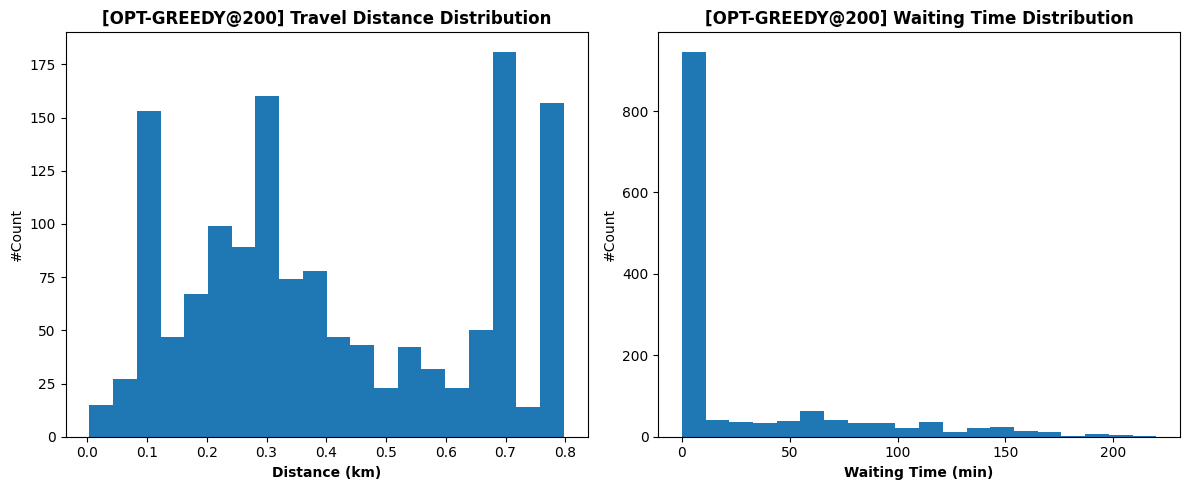

In [103]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

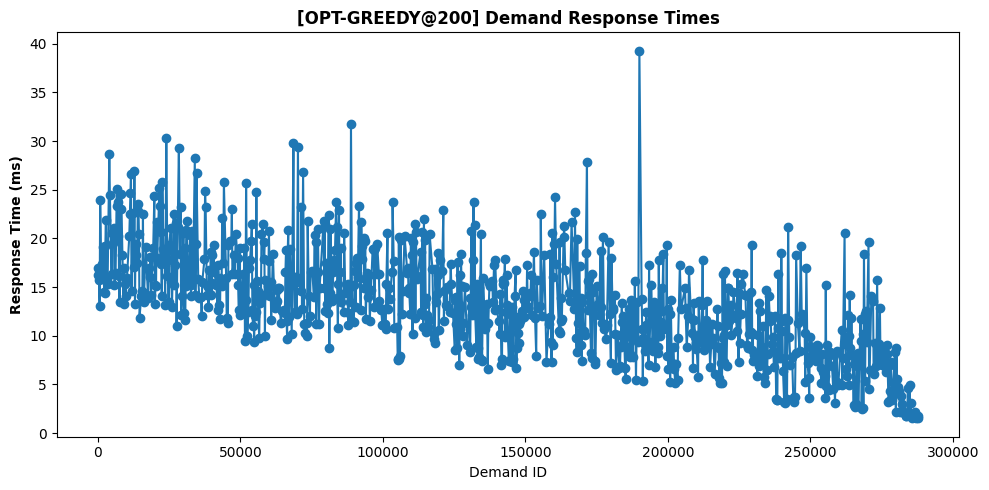

In [104]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

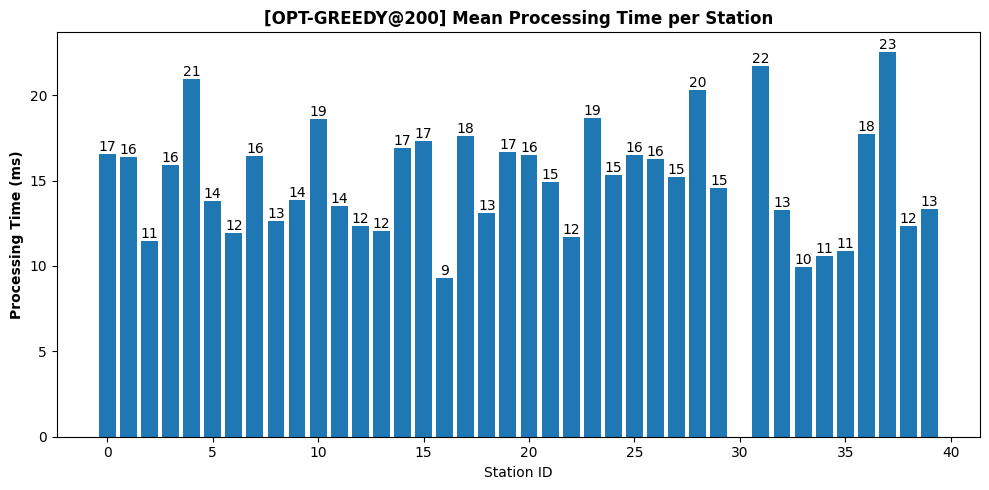

In [105]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [106]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/200cars


##### *Initialisation*

In [107]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [108]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:22:04.813 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-28 23:22:07.549 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-28 23:22:09.867 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-28 23:22:12.488 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-28 23:22:13.426 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-28 23:22:15.122 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-28 23:22:15.901 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-28 23:22:17.685 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-28 23:22:19.653 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-28 23:22:21.935 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-28 23:22:23.457 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [109]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 8.21 kWh
  Station 1: 2.99 kWh
  Station 2: 39.83 kWh
  Station 3: 10.53 kWh
  Station 4: 47.60 kWh
  Station 5: 45.77 kWh
  Station 6: 91.83 kWh
  Station 7: 91.73 kWh
  Station 8: 76.85 kWh
  Station 9: 7.32 kWh
  Station 10: 3.38 kWh
  Station 11: 21.13 kWh
  Station 12: 11.07 kWh
  Station 13: 67.33 kWh
  Station 14: 13.91 kWh
  Station 15: 79.98 kWh
  Station 16: 17.69 kWh
  Station 17: 169.49 kWh
  Station 18: 49.07 kWh
  Station 19: 7.35 kWh
  Station 20: 29.20 kWh
  Station 21: 199.82 kWh
  Station 22: 69.27 kWh
  Station 23: 53.31 kWh
  Station 24: 11.78 kWh
  Station 25: 48.41 kWh
  Station 26: 99.67 kWh
  Station 27: 73.64 kWh
  Station 28: 17.96 kWh
  Station 29: 17.68 kWh
  Station 30: 8.04 kWh
  Station 31: 10.64 kWh
  Station 32: 52.58 kWh
  Station 33: 97.47 kWh
  Station 34: 10.35 kWh
  Station 35: 21.57 kWh
  Station 36: 210.53 kWh
  Station 37: 69.38 kWh
  Station 38: 235.54 kWh
  Station 39:

In [110]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

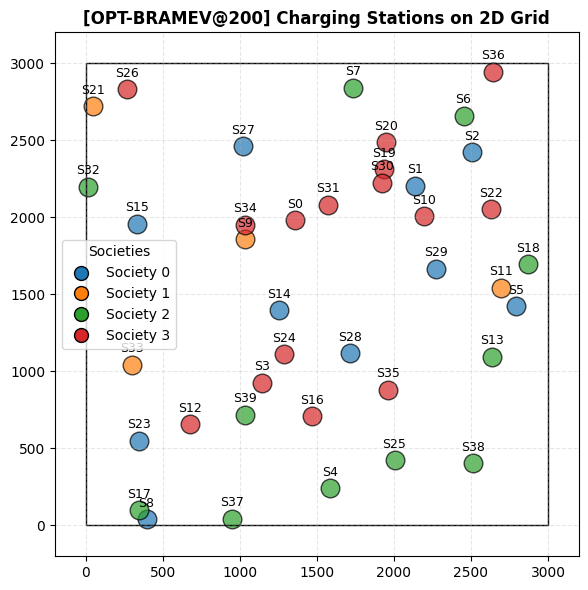

In [111]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

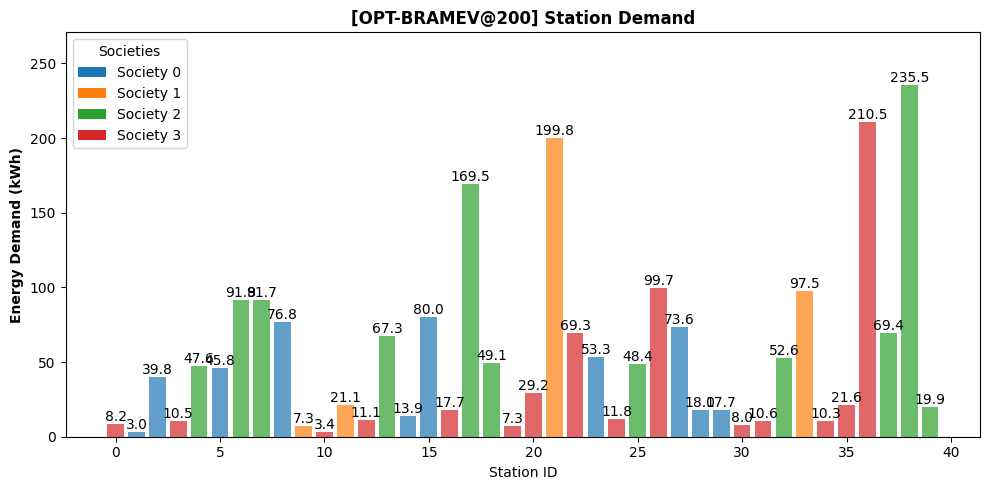

In [112]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

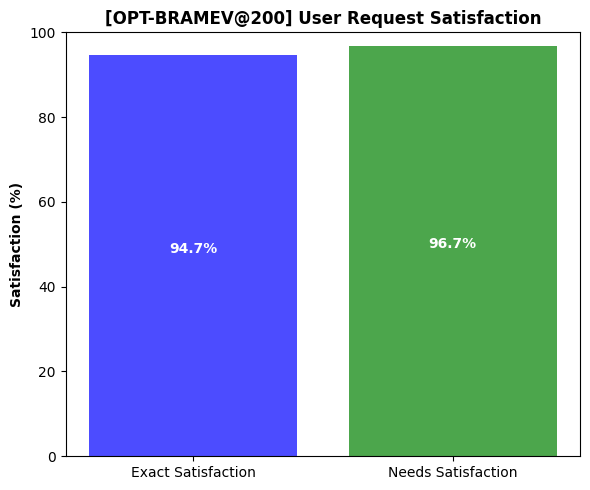

In [113]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

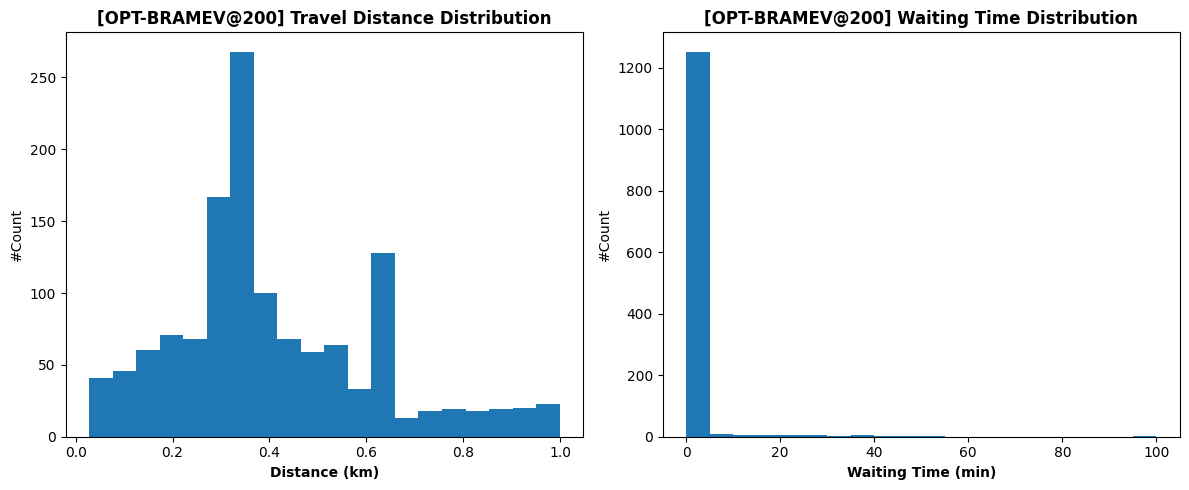

In [114]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

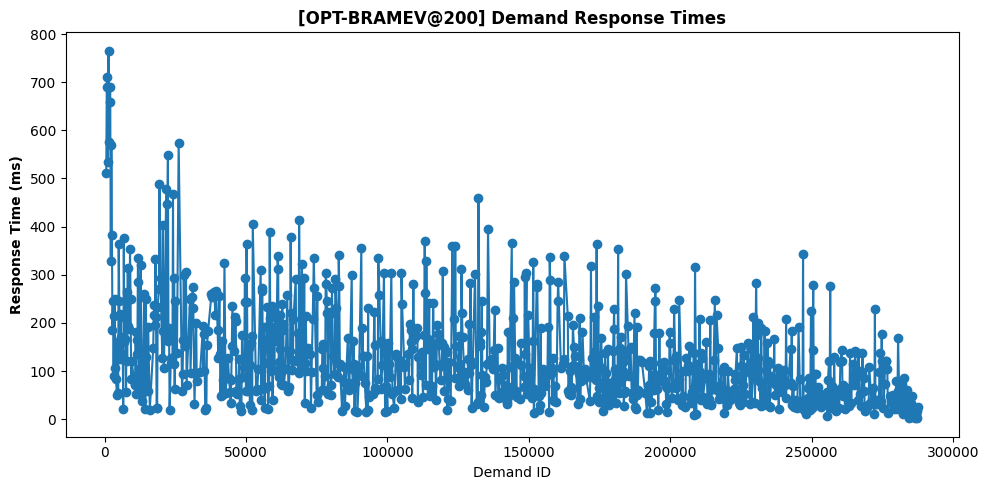

In [115]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

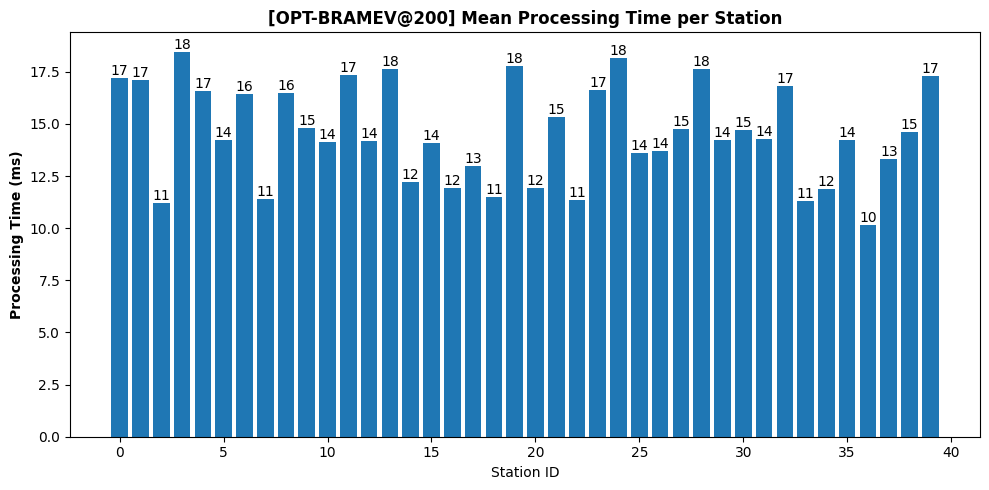

In [116]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [117]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

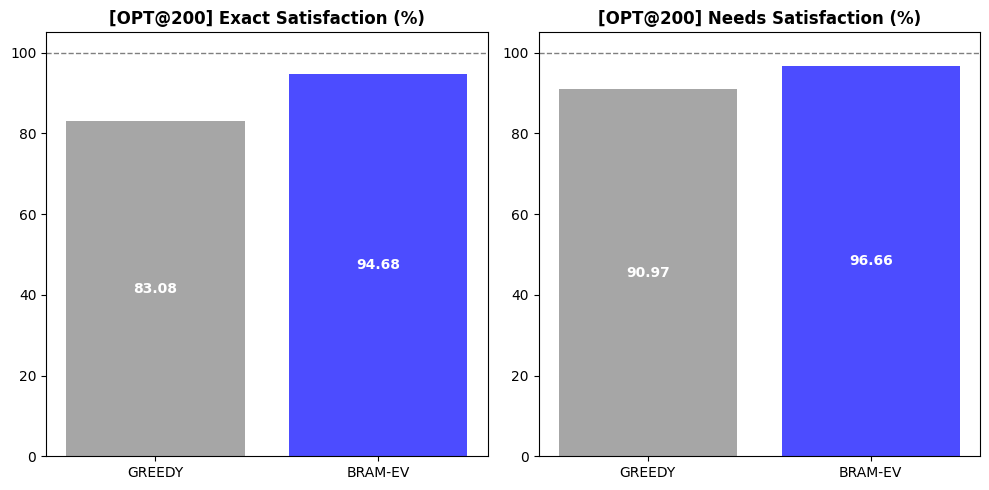

In [118]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

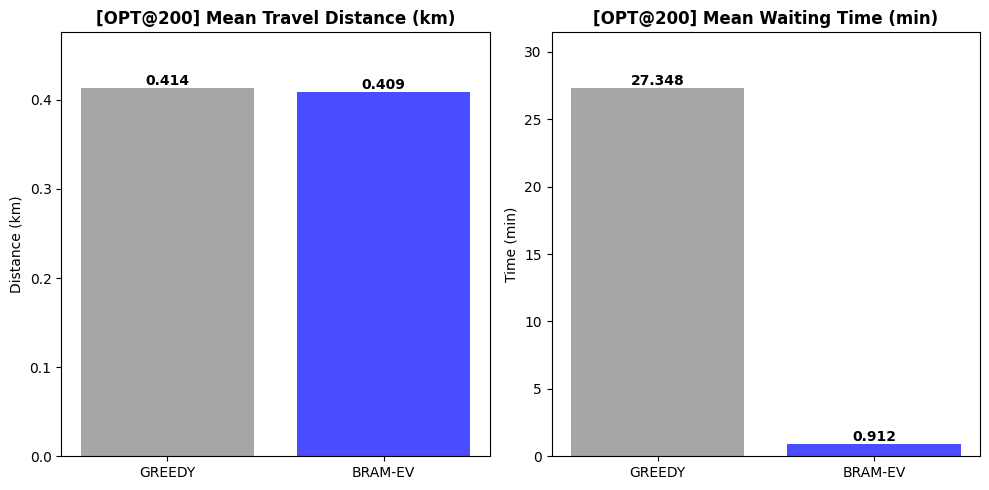

In [119]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

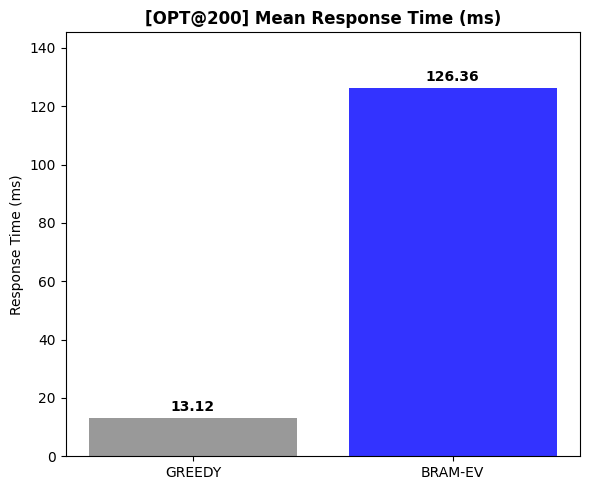

In [120]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [121]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [122]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/250cars


##### *Initialisation*

In [123]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [124]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:24:03.760 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-28 23:24:03.999 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-28 23:24:04.409 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-28 23:24:04.790 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-28 23:24:05.030 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-28 23:24:05.399 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-28 23:24:05.777 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-28 23:24:06.093 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-28 23:24:06.459 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-28 23:24:06.709 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-28 23:24:07.122 | IN

##### *Metrics*

In [125]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 12.72 kWh
  Station 1: 14.07 kWh
  Station 2: 339.78 kWh
  Station 3: 102.07 kWh
  Station 4: 7.05 kWh
  Station 5: 21.22 kWh
  Station 6: 175.47 kWh
  Station 7: 91.70 kWh
  Station 8: 4.87 kWh
  Station 9: 3.20 kWh
  Station 10: 11.56 kWh
  Station 11: 129.12 kWh
  Station 12: 9.33 kWh
  Station 13: 89.58 kWh
  Station 14: 370.73 kWh
  Station 15: 7.97 kWh
  Station 16: 256.45 kWh
  Station 17: 68.22 kWh
  Station 18: 7.25 kWh
  Station 19: 13.76 kWh
  Station 20: 63.83 kWh
  Station 21: 0.00 kWh
  Station 22: 8.43 kWh
  Station 23: 1.83 kWh
  Station 24: 14.59 kWh
  Station 25: 22.99 kWh
  Station 26: 0.00 kWh
  Station 27: 53.47 kWh
  Station 28: 16.16 kWh
  Station 29: 130.33 kWh
  Station 30: 7.30 kWh
  Station 31: 4.16 kWh
  Station 32: 9.35 kWh
  Station 33: 19.87 kWh
  Station 34: 3.92 kWh
  Station 35: 150.06 kWh
  Station 36: 19.07 kWh
  Station 37: 23.86 kWh
  Station 38: 337.24 kWh
  Station 39: 18

In [126]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

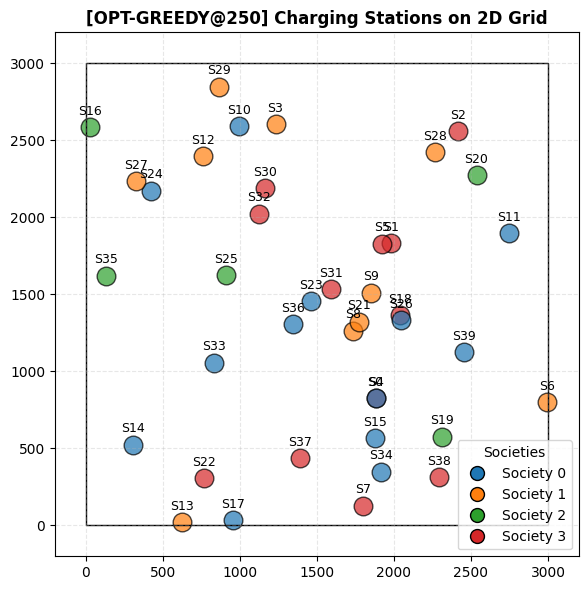

In [127]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

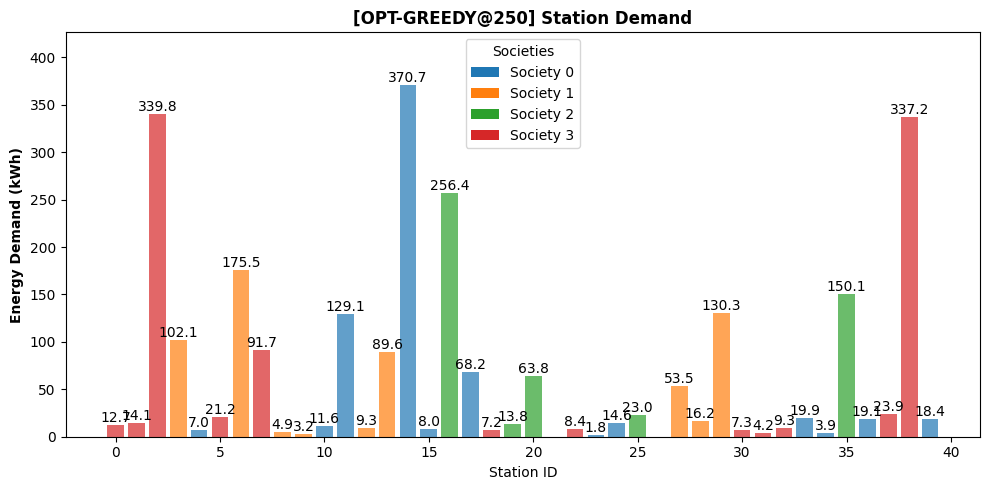

In [128]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

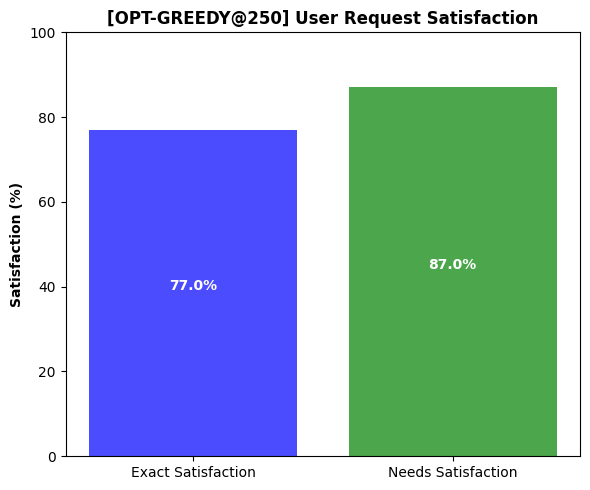

In [129]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

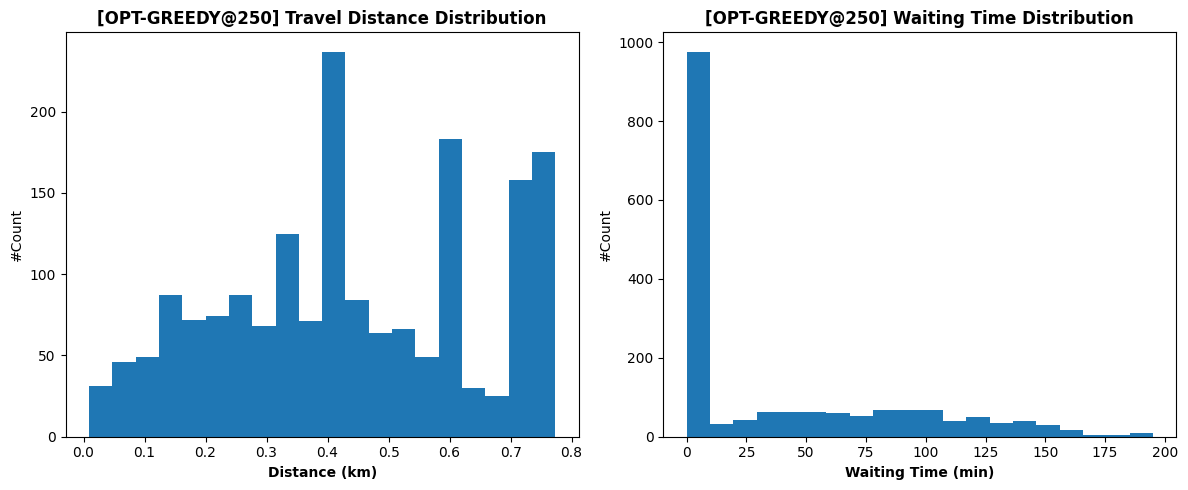

In [130]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

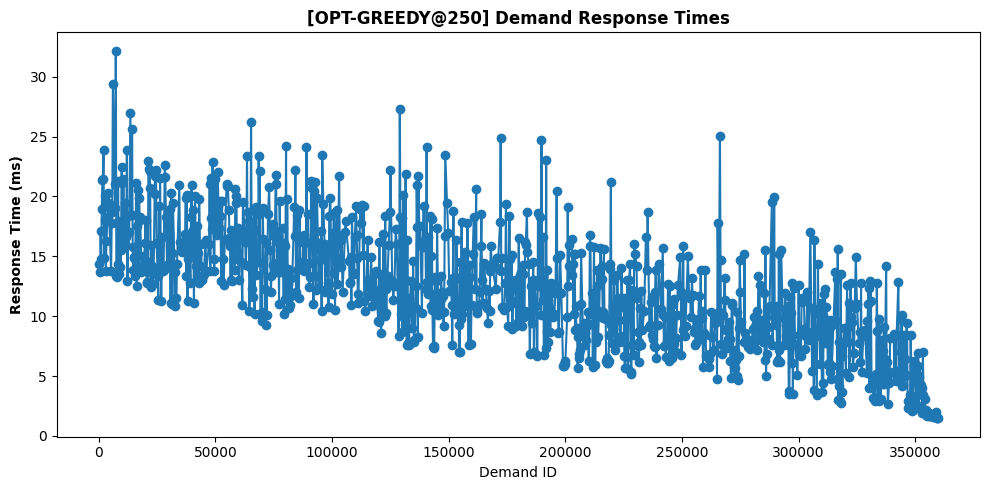

In [131]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

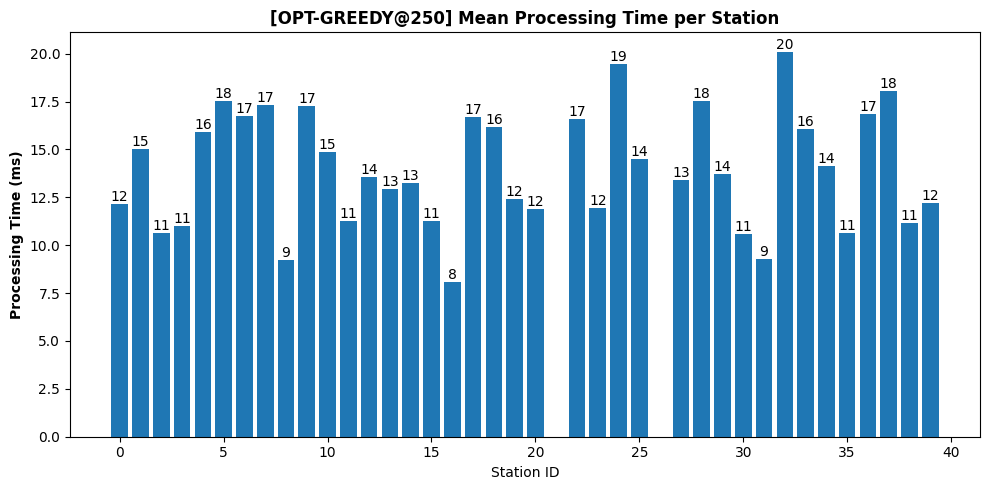

In [132]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [133]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/250cars


##### *Initialisation*

In [134]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [135]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-28 23:24:37.190 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-28 23:24:42.613 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-28 23:24:45.592 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-28 23:24:48.859 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-28 23:24:52.341 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-28 23:24:55.632 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-28 23:24:58.833 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-28 23:25:01.566 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-28 23:25:03.948 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-28 23:25:07.932 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-28 23:25:12.316 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [136]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 230.35 kWh
  Station 1: 181.82 kWh
  Station 2: 56.75 kWh
  Station 3: 37.93 kWh
  Station 4: 52.24 kWh
  Station 5: 41.14 kWh
  Station 6: 118.12 kWh
  Station 7: 42.04 kWh
  Station 8: 88.45 kWh
  Station 9: 49.50 kWh
  Station 10: 36.27 kWh
  Station 11: 34.98 kWh
  Station 12: 191.47 kWh
  Station 13: 54.33 kWh
  Station 14: 104.57 kWh
  Station 15: 6.32 kWh
  Station 16: 143.25 kWh
  Station 17: 22.78 kWh
  Station 18: 284.93 kWh
  Station 19: 107.75 kWh
  Station 20: 77.87 kWh
  Station 21: 59.60 kWh
  Station 22: 27.43 kWh
  Station 23: 58.54 kWh
  Station 24: 102.16 kWh
  Station 25: 138.72 kWh
  Station 26: 10.60 kWh
  Station 27: 89.83 kWh
  Station 28: 18.82 kWh
  Station 29: 12.35 kWh
  Station 30: 12.40 kWh
  Station 31: 3.73 kWh
  Station 32: 91.41 kWh
  Station 33: 24.85 kWh
  Station 34: 61.58 kWh
  Station 35: 10.13 kWh
  Station 36: 42.74 kWh
  Station 37: 12.51 kWh
  Station 38: 15.40 kWh
  S

In [137]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

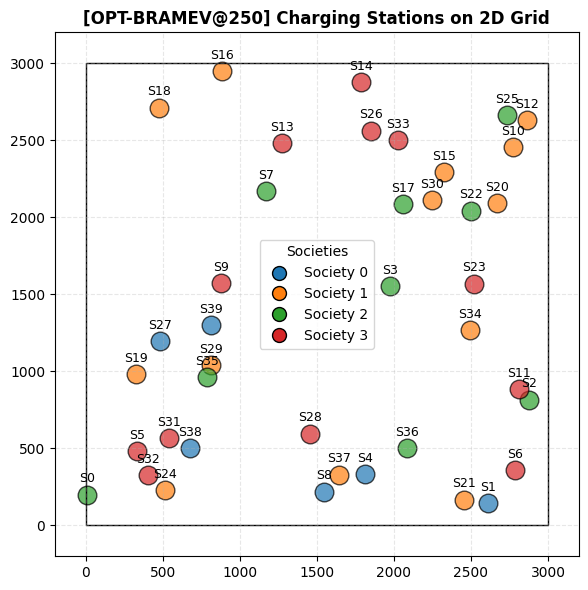

In [138]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

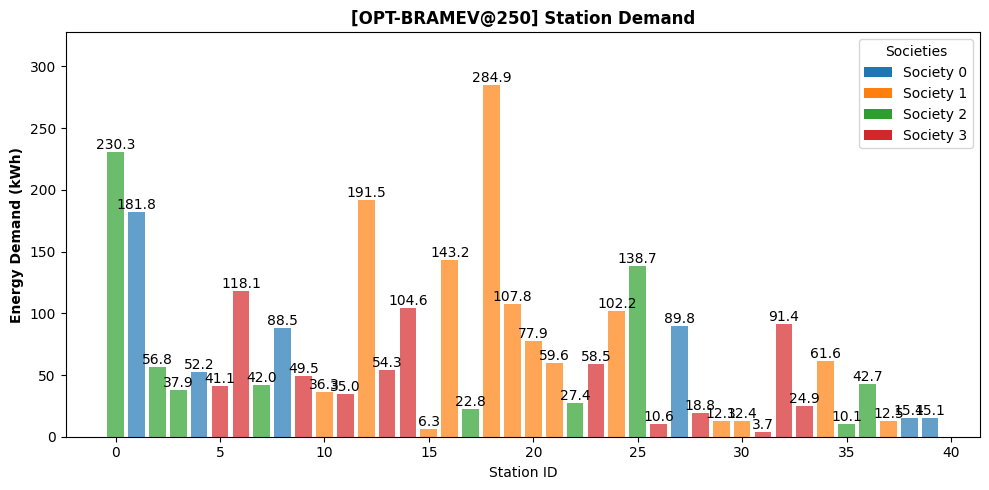

In [139]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

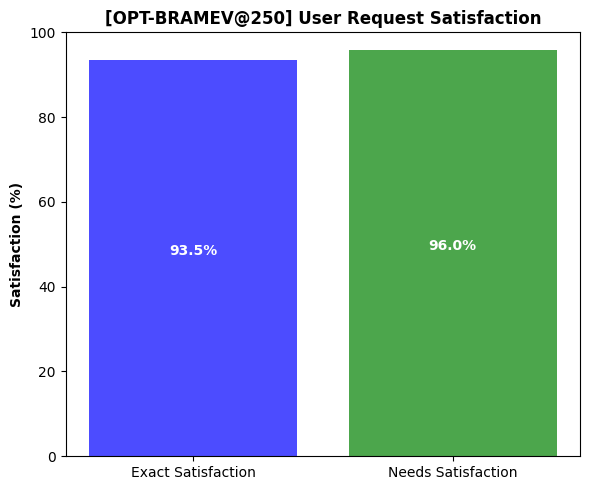

In [140]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

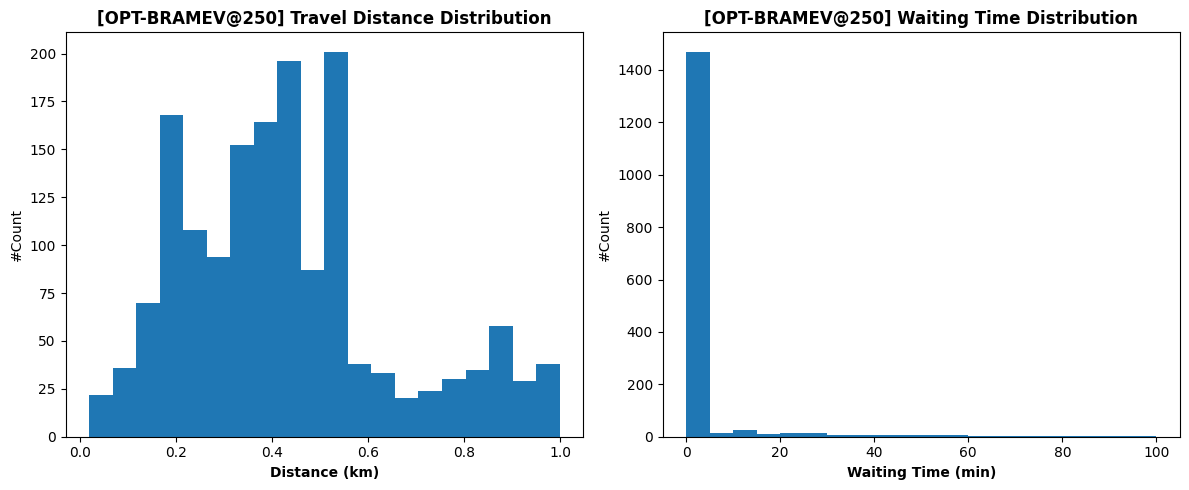

In [141]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

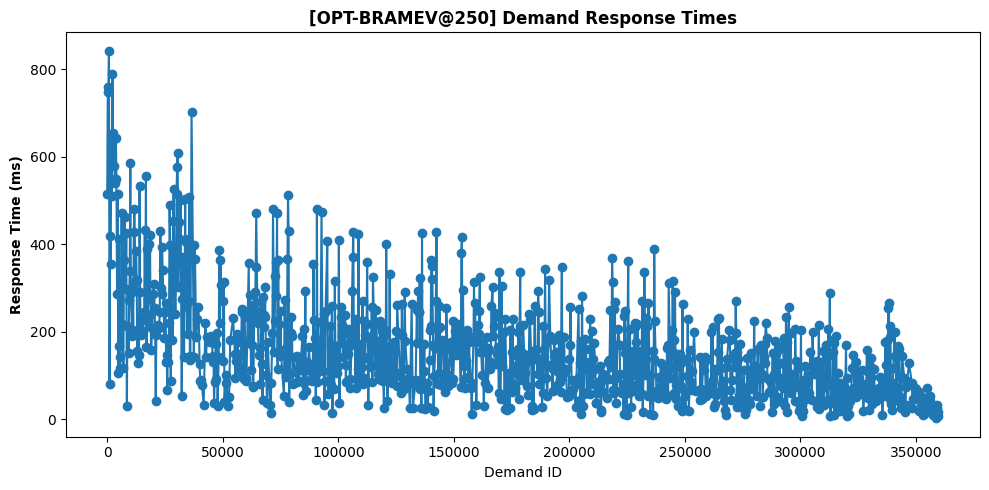

In [142]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

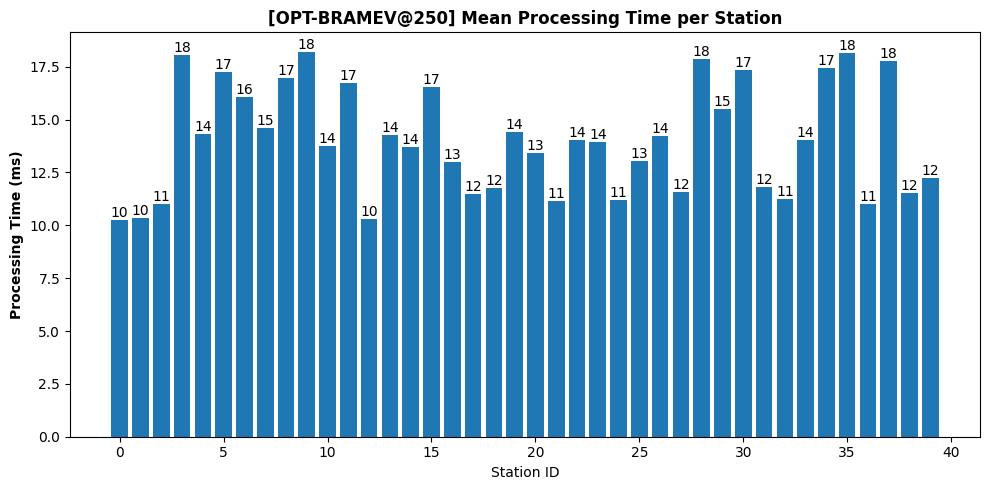

In [143]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [144]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

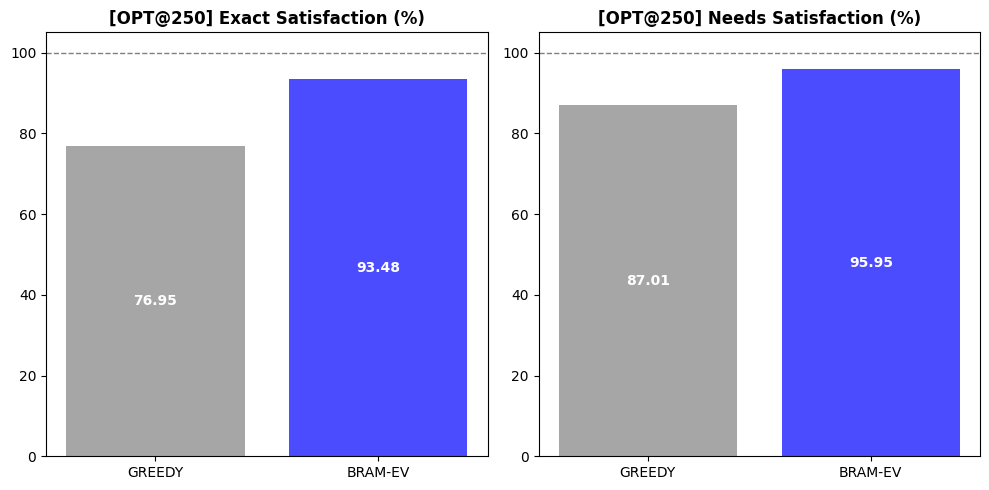

In [145]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

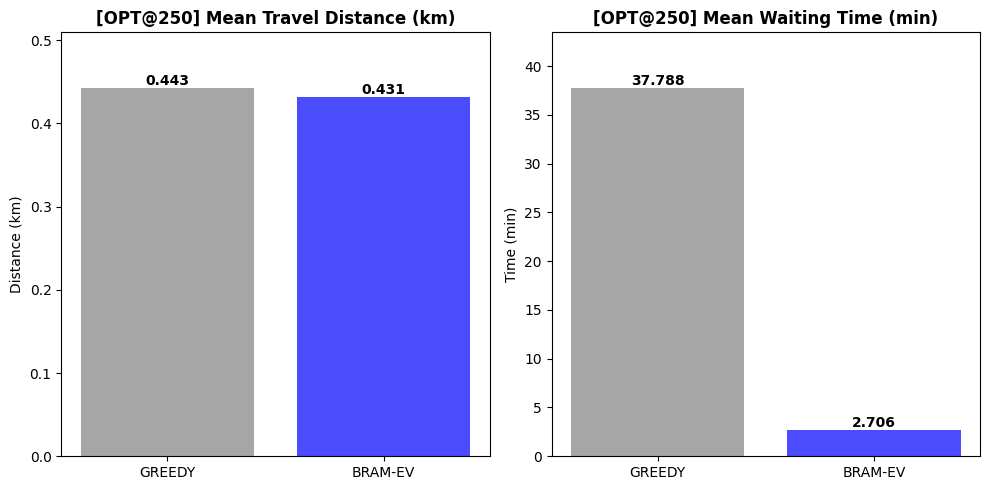

In [146]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

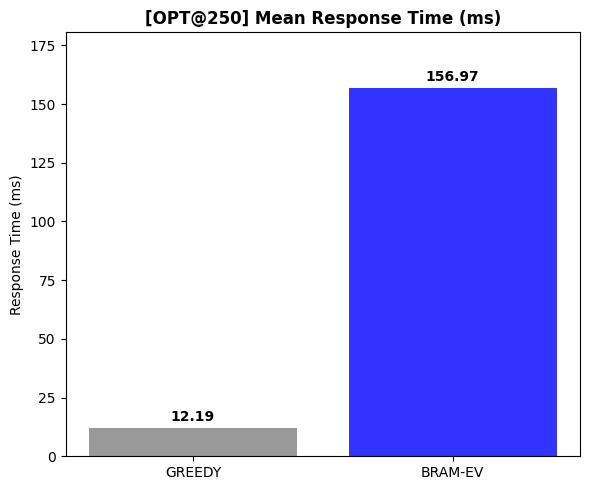

In [147]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

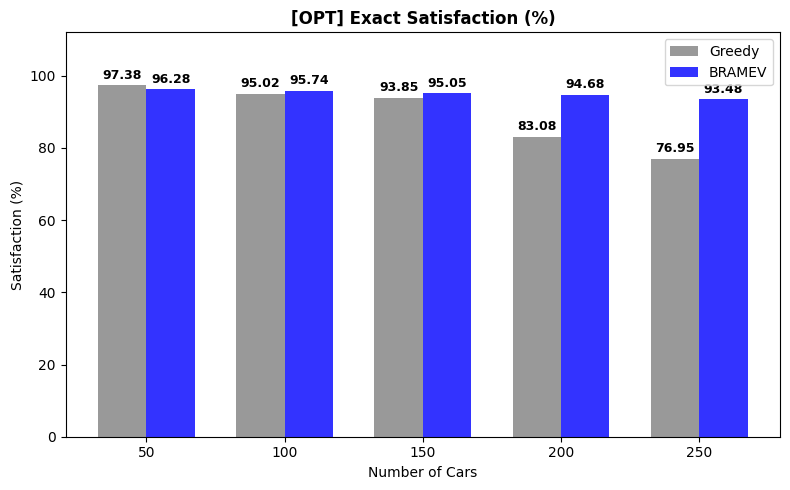

In [148]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

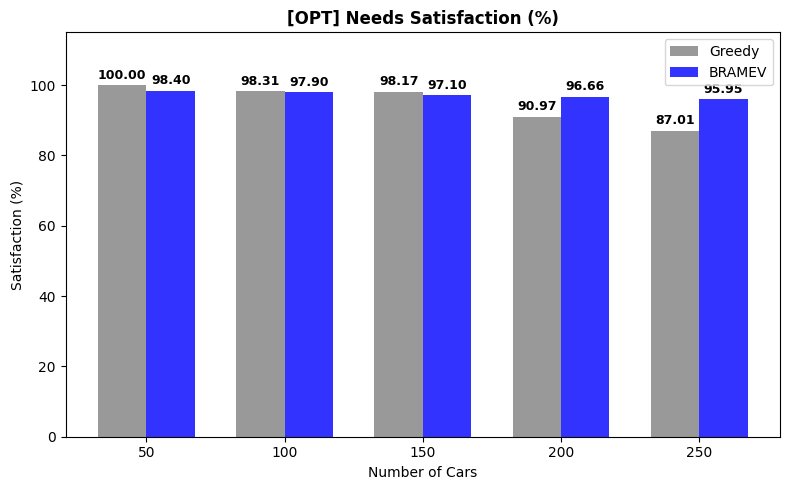

In [149]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

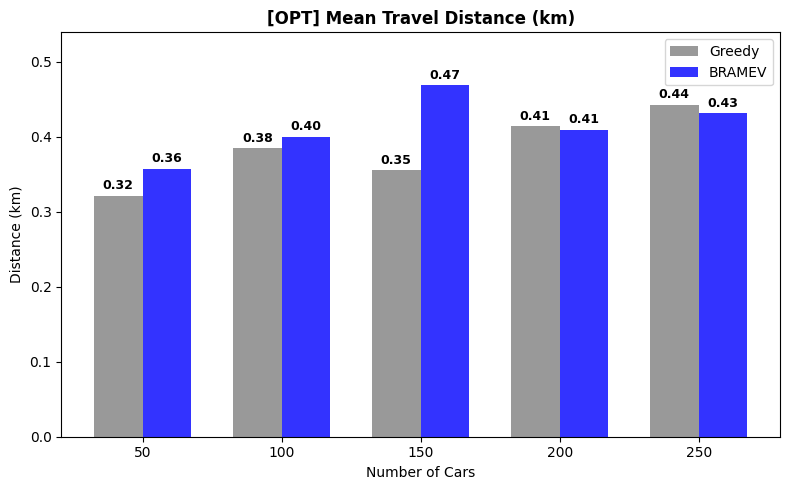

In [150]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


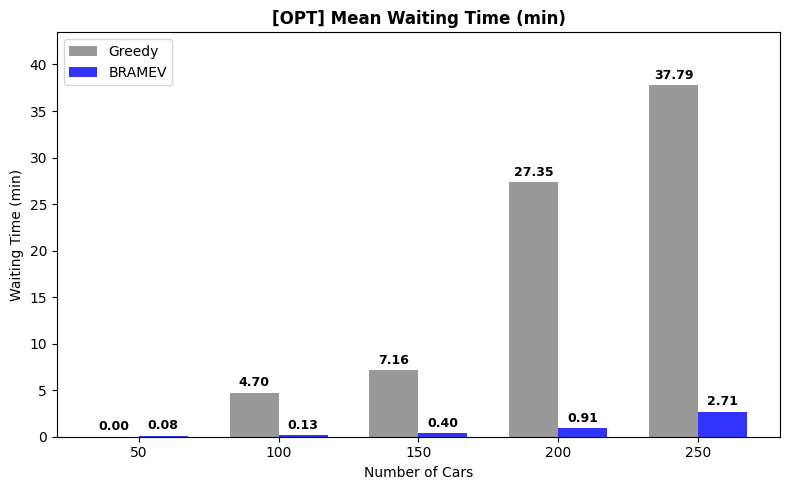

In [151]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


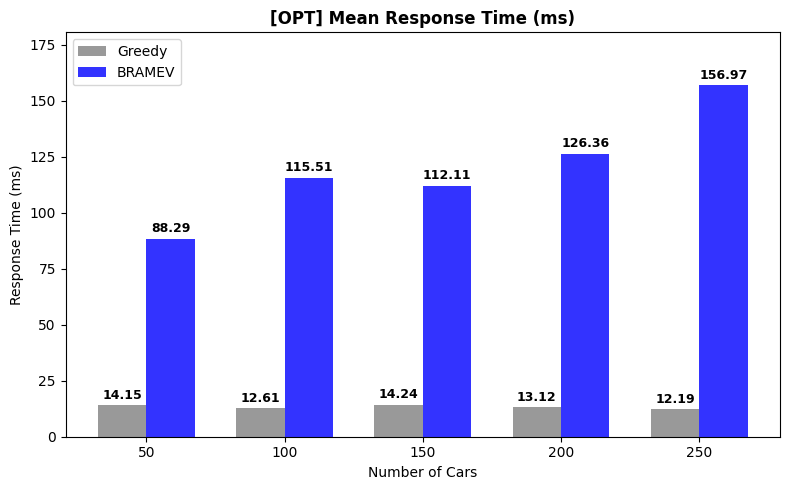

In [152]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
